In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_datalo = f'../data/quaia_G20.0.fits'
fn_datahi = f'../data/quaia_G20.5.fits'

fn_datalo_zbin0 = f'../data/quaia_G20.0_zsplit2bin0.fits'
fn_datalo_zbin1 = f'../data/quaia_G20.0_zsplit2bin1.fits'

fn_datahi_zbin0 = f'../data/quaia_G20.5_zsplit2bin0.fits'
fn_datahi_zbin1 = f'../data/quaia_G20.5_zsplit2bin1.fits'

fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

fn_randlo_zbin0 = f'../data/randoms/random_G20.0_zsplit2bin0_10x.fits'
fn_randlo_zbin1 = f'../data/randoms/random_G20.0_zsplit2bin1_10x.fits'

fn_randhi_zbin0 = f'../data/randoms/random_G20.5_zsplit2bin0_10x.fits'
fn_randhi_zbin1 = f'../data/randoms/random_G20.5_zsplit2bin1_10x.fits'

In [4]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

In [5]:
fn_sello_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin0.fits'
fn_sello_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin1.fits'

fn_selhi_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin0.fits'
fn_selhi_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin1.fits'

## Parameters

In [6]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [7]:
G_hi = 20.5
G_lo = 20.0

In [8]:
nthreads = 18

In [9]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [10]:
selfunc_hi_zbin0 = hp.fitsfunc.read_map(fn_selhi_zbin0)
selfunc_hi_zbin1 = hp.fitsfunc.read_map(fn_selhi_zbin1)

In [11]:
mask_type = 'selfunc'

# Visuals

In [12]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, mask_type = 'selfunc')

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [13]:
cmap_reds = sns.color_palette("Reds_r", as_cmap = True)
cmap_blues = sns.color_palette("Blues_r", as_cmap = True)

In [14]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [15]:
z_array = [0,1]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(z_array)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_red, cmap_blue]

In [16]:
blue = np.mean(cmap_blue, axis = 0)
red = np.mean(cmap_red, axis = 0)

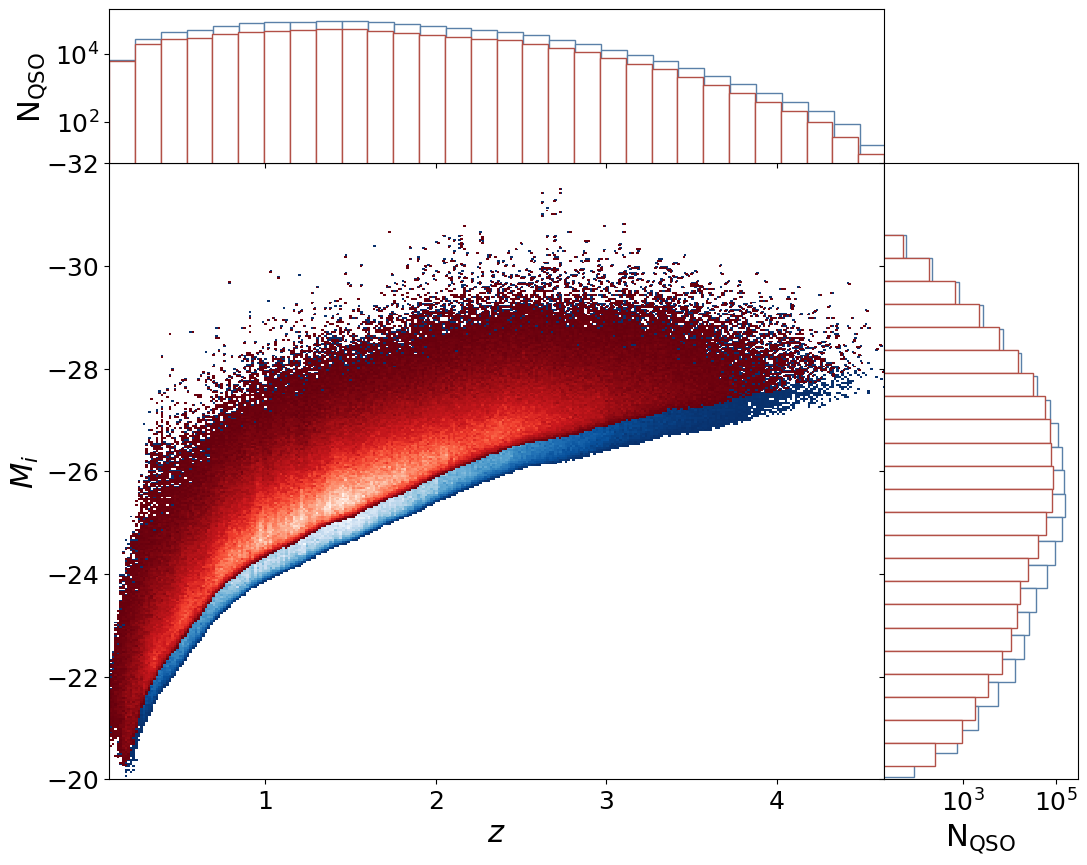

In [17]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
                                       cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in joint L z bins

In [18]:
L_bins = np.array([-32.0, -27.0, -26.0, -25.0, -20.0])
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
L_array = range(len(L_bins)-1)
z_array = range(len(z_bins)-1)
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmaps = [cmap_red, cmap_blue]
tabs = [tab_datalo[mask_datalo], tab_datahi[mask_datahi]]
G_array = [20.0, 20.5]
L_labels = ['${}<M_i\leq{}$'.format(L_bins[L], L_bins[L+1]) for L in range(len(L_bins[:-1]))]
z_labels = ['${}<z\leq{}$'.format(z_bins[L], z_bins[L+1]) for L in range(len(z_bins[:-1]))]
mask = 40

G20.0_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0: 0.40              1038 vs 1730
G20.0_zmin0.0zmax1.0_Lmin-27.0Lmax-26.0: 0.40              5947 vs 9911
G20.0_zmin0.0zmax1.0_Lmin-26.0Lmax-25.0: 0.40              23500 vs 39167
G20.0_zmin0.0zmax1.0_Lmin-25.0Lmax-20.0: 0.40              89982 vs 149969
G20.0_zmin1.0zmax2.0_Lmin-32.0Lmax-27.0: 0.40              21787 vs 36311
G20.0_zmin1.0zmax2.0_Lmin-27.0Lmax-26.0: 0.40              79598 vs 132662
G20.0_zmin1.0zmax2.0_Lmin-26.0Lmax-25.0: 0.40              103913 vs 173186
G20.0_zmin1.0zmax2.0_Lmin-25.0Lmax-20.0: 0.40              16299 vs 27165
G20.0_zmin2.0zmax3.0_Lmin-32.0Lmax-27.0: 0.40              57256 vs 95423
G20.0_zmin2.0zmax3.0_Lmin-27.0Lmax-26.0: 0.40              41783 vs 69636
G20.0_zmin2.0zmax3.0_Lmin-26.0Lmax-25.0: 0.40              127 vs 211
G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-32.0Lmax-27.0: 0.40              12221 vs 20368
G20.0_zmin3.0zmax4.6_Lmin-27.0Lmax-

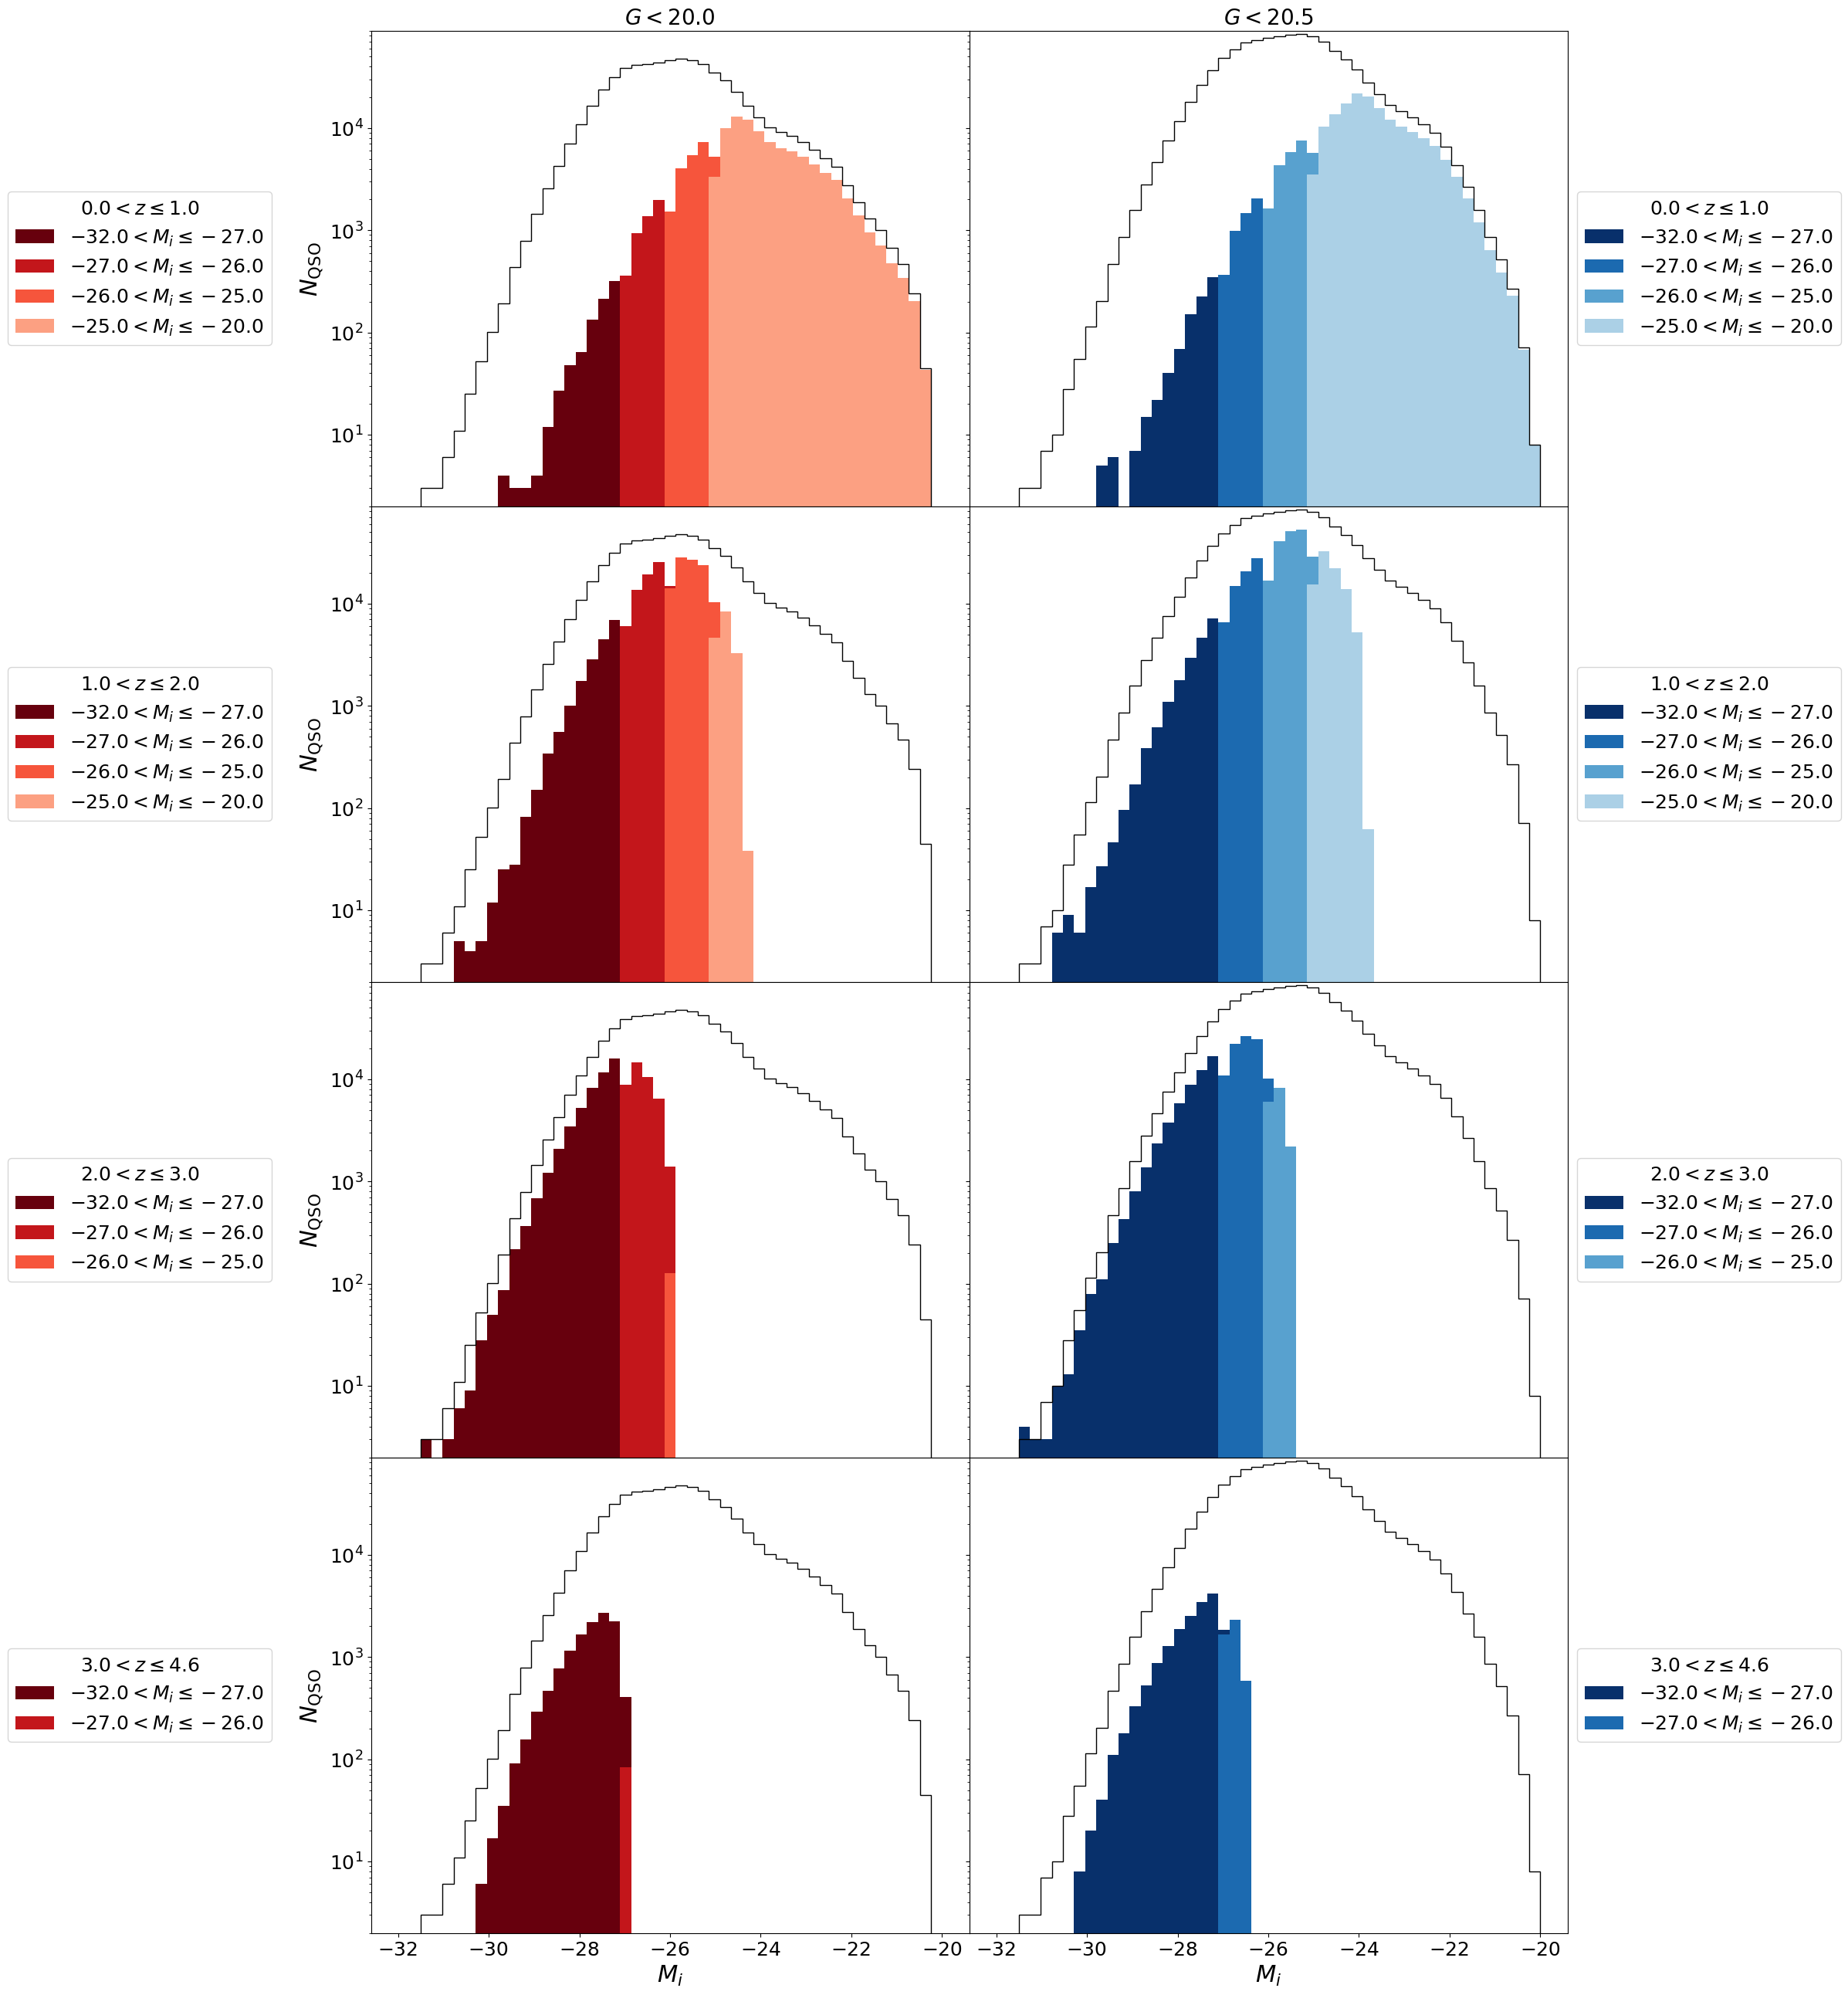

In [19]:
# plot data
bins = np.linspace(-32,-20)

# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)
locs = ['center right', 'center left']
x = [-0.15, 1]
for i in range(len(G_array)):

    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        ax1.hist(tabs[i]['M_i'], bins=bins, histtype = 'step', color='black')
        
        for k in L_array:
        
            try:
                tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_array[i], [j,k], True, ['z', 'L'], 
                                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                     method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                     n_bins = [None, None], mask = mask, 
                                                                                                     norm = 'percentile')
                ax1.hist(tab_datahi_mask_zbin0['M_i'], label = L_labels[k], bins = bins, color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))

        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if j == 3:
            ax1.set_xlabel('$M_i$')
        else:
            ax1.set_xticklabels([])
        ax1.set_yscale('log')
        ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5), title = '${}<z\leq{}$'.format(z_bins[j], z_bins[j+1]), title_fontsize = 18)
        ax1.set_ylim(2, 9e4)
        if i>0:
            ax1.set_yticklabels([])
        else:
            ax1.set_ylabel('$N_\mathrm{QSO}$')

plt.show()

In [ ]:
# plot data
bins = np.linspace(0, 4.6)

# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)
locs = ['center right', 'center left']
x = [-0.15, 1]
N = {G_lo: [], G_hi: []}
for i in range(len(G_array)):

    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        ax1.hist(tabs[i]['redshift_quaia'], bins=bins, histtype = 'step', color='black')
        
        N_z = []
        
        for k in z_array:
        
            try:
                tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_array[i], [k,j], True, ['z', 'L'], 
                                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                     method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                     n_bins = [None, None], mask = mask, 
                                                                                                     norm = 'percentile')
                N_z.append(len(tab_datahi_mask_zbin0))
                ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = z_labels[k], bins = bins, color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        N[G_array[i]].append(N_z)

        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if j == 3:
            ax1.set_xlabel('$z$')
        else:
            ax1.set_xticklabels([])
        ax1.set_yscale('log')
        ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5), title = '${}<M_i\leq{}$'.format(L_bins[j], L_bins[j+1]), title_fontsize = 18)
        ax1.set_ylim(2, 9e4)
        if i>0:
            ax1.set_yticklabels([])
        else:
            ax1.set_ylabel('$N_\mathrm{QSO}$')

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (25, 10))
gs = gridspec.GridSpec(2, 4, hspace = 0, height_ratios=[1,4], width_ratios=[4,1,4,1], wspace = 0)

ax1 = fig.add_subplot(gs[4])
ax1_hi = fig.add_subplot(gs[6])

quaia.absolute(tab_datahi, G_hi)
quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1_hi.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
                                       cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
                                       cmin = 1)
    
for ax, G, color in zip([ax1, ax1_hi], G_array, [red, blue]):
    
    for L_bin, xmax in zip(L_bins, [z_bins[4], z_bins[4], z_bins[4], z_bins[3], z_bins[2]]):
        ax.hlines(L_bin, color = 'black', xmin = z_bins[0], xmax = xmax, linewidth = 1)
    for z_bin, ymax in zip(z_bins, [L_bins[4], L_bins[4], L_bins[4], L_bins[3], L_bins[2]]):
        ax.vlines(z_bin, color = 'black', ymin = L_bins[0], ymax = ymax, linewidth = 1)
    
    for i in z_array:
        for j in L_array:
            try:
                ax.text(quaia.recenter(z_bins)[i]-0.25, quaia.recenter(L_bins)[j]+0.125, N[G][j][i], fontsize = 18, color = color, bbox=dict(facecolor='white'))
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G, z_bins[i], z_bins[i+1], L_bins[j], 
                                                                                                      L_bins[j+1]))
ax1.set_ylabel('$M_i$')
xlim = ax1.get_xlim()
# ylim = ax1.get_ylim()
for ax in [ax1, ax1_hi]:
    ax.set_xlabel('$z$')
    ax.set_ylim(-20, -32)
    ax.set_xlim(xlim[0], z_bins[-1])
ax1_hi.set_yticklabels([])

ax2 = fig.add_subplot(gs[0])
ax2_hi = fig.add_subplot(gs[2])
ax2_hi.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
ax2.set_title('$G<{}$'.format(G_lo))
ax2_hi.set_title('$G<{}$'.format(G_hi))
ax2.set_ylabel('N$_\mathrm{QSO}$')
for ax in [ax2, ax2_hi]:
    ax.set_yscale('log')
    ax.set_xlim(xlim[0], z_bins[-1])
    ax.set_ylim(6,2e5)
    ax.set_xticklabels([])

ax3 = fig.add_subplot(gs[5])
ax3_hi = fig.add_subplot(gs[7])
ax3_hi.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
for ax in [ax3, ax3_hi]:
    ax.set_xlabel('N$_\mathrm{QSO}$')
    ax.set_xscale('log')
    ax.set_yticklabels([])
    ax.set_ylim(-20, -32)
    ax.set_xlim(2e1,2e5)

plt.show()

# # plot!
# fig = plt.figure(figsize = (12.5, 10))
# gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

# ax1 = fig.add_subplot(gs[2])

# quaia.absolute(tab_datahi, G_hi)
# quaia.absolute(tab_datalo, G_lo)
# h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
#                                        cmin = 1)
# # h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
# #                                        cmin = 1)
# for L_bin, xmax in zip(L_bins, [z_bins[4], z_bins[4], z_bins[4], z_bins[3], z_bins[2]]):
#     ax1.hlines(L_bin, color = 'black', xmin = z_bins[0], xmax = xmax, linewidth = 1)
# for z_bin, ymax in zip(z_bins, [L_bins[4], L_bins[4], L_bins[4], L_bins[3], L_bins[2]]):
#     ax1.vlines(z_bin, color = 'black', ymin = L_bins[0], ymax = ymax, linewidth = 1)
    
# for i in z_array:
    
#     for j in L_array:
        
#         try:
#             ax1.text(quaia.recenter(z_bins)[i]-0.25, quaia.recenter(L_bins)[j]+0.125, N[G_hi][j][i], fontsize = 18, color = blue, bbox=dict(facecolor='white'))
#         except:
#             print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_hi, z_bins[i], z_bins[i+1], L_bins[j], 
#                                                                                                       L_bins[j+1]))
#             # ax1.text(quaia.recenter(z_bins)[i]-0.25, quaia.recenter(L_bins)[j]+0.125, 0, fontsize = 18, bbox=dict(facecolor='white'))
# # for L_bin in L_bins:
# #     ax1.axhline(L_bin, color = 'black')
# # for z_bin in z_bins:
#     # ax1.axvline(z_bin, color = 'black')
# # ax1.fill_between(np.linspace(z_bins[3], z_bins[4]), L_bins[2], L_bins[3], color = 'red', alpha = 0.25)
# # ax1.fill_between(np.linspace(z_bins[2], z_bins[4]), L_bins[3], L_bins[4], color = 'red', alpha = 0.25)
# ax1.set_ylabel('$M_i$')
# ax1.set_xlabel('$z$')
# ax1.set_ylim(-20, -32)
# # xlim = ax1.get_xlim()
# ylim = ax1.get_ylim()
# ax1.set_xlim(z_bins[0], z_bins[-1])

# ax2 = fig.add_subplot(gs[0])
# ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
# # ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
# ax2.set_title('$G<{}$'.format(G_hi))
# ax2.set_ylabel('N$_\mathrm{QSO}$')
# ax2.set_yscale('log')
# ax2.set_xlim(z_bins[0], z_bins[-1])
# ax2.set_ylim(6,2e5)
# ax2.set_xticklabels([])

# ax3 = fig.add_subplot(gs[3])
# ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
# # ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
# ax3.set_xlabel('N$_\mathrm{QSO}$')
# ax3.set_xscale('log')
# ax3.set_yticklabels([])
# ax3.set_ylim(ylim)
# ax3.set_xlim(2e1,3e5)

# plt.show()

## $\xi(s)$

In [22]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
sbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [23]:
# plot data
# bins = np.linspace(-32,-20)
cf = {G_lo: [], G_hi: []}

# # plot!
for i in range(len(G_array)):
    
    for j in z_array:
        
        cf_L = []
        for k in L_array:
        
            try:
                tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_array[i], [j,k], True, ['z', 'L'], 
                                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                     method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                     n_bins = [None, None], mask = mask, 
                                                                                                     norm = 'percentile')
                cf_L.append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = sbins))
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        cf[G_array[i]].append(cf_L)

G20.0_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0: 0.40              1038 vs 1730


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.0_zmin0.0zmax1.0_Lmin-27.0Lmax-26.0: 0.40              5947 vs 9911


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.0_zmin0.0zmax1.0_Lmin-26.0Lmax-25.0: 0.40              23500 vs 39167


...

G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-32.0Lmax-27.0: 0.40              17315 vs 28856


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.6_Lmin-27.0Lmax-26.0: 0.40              4561 vs 7600


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


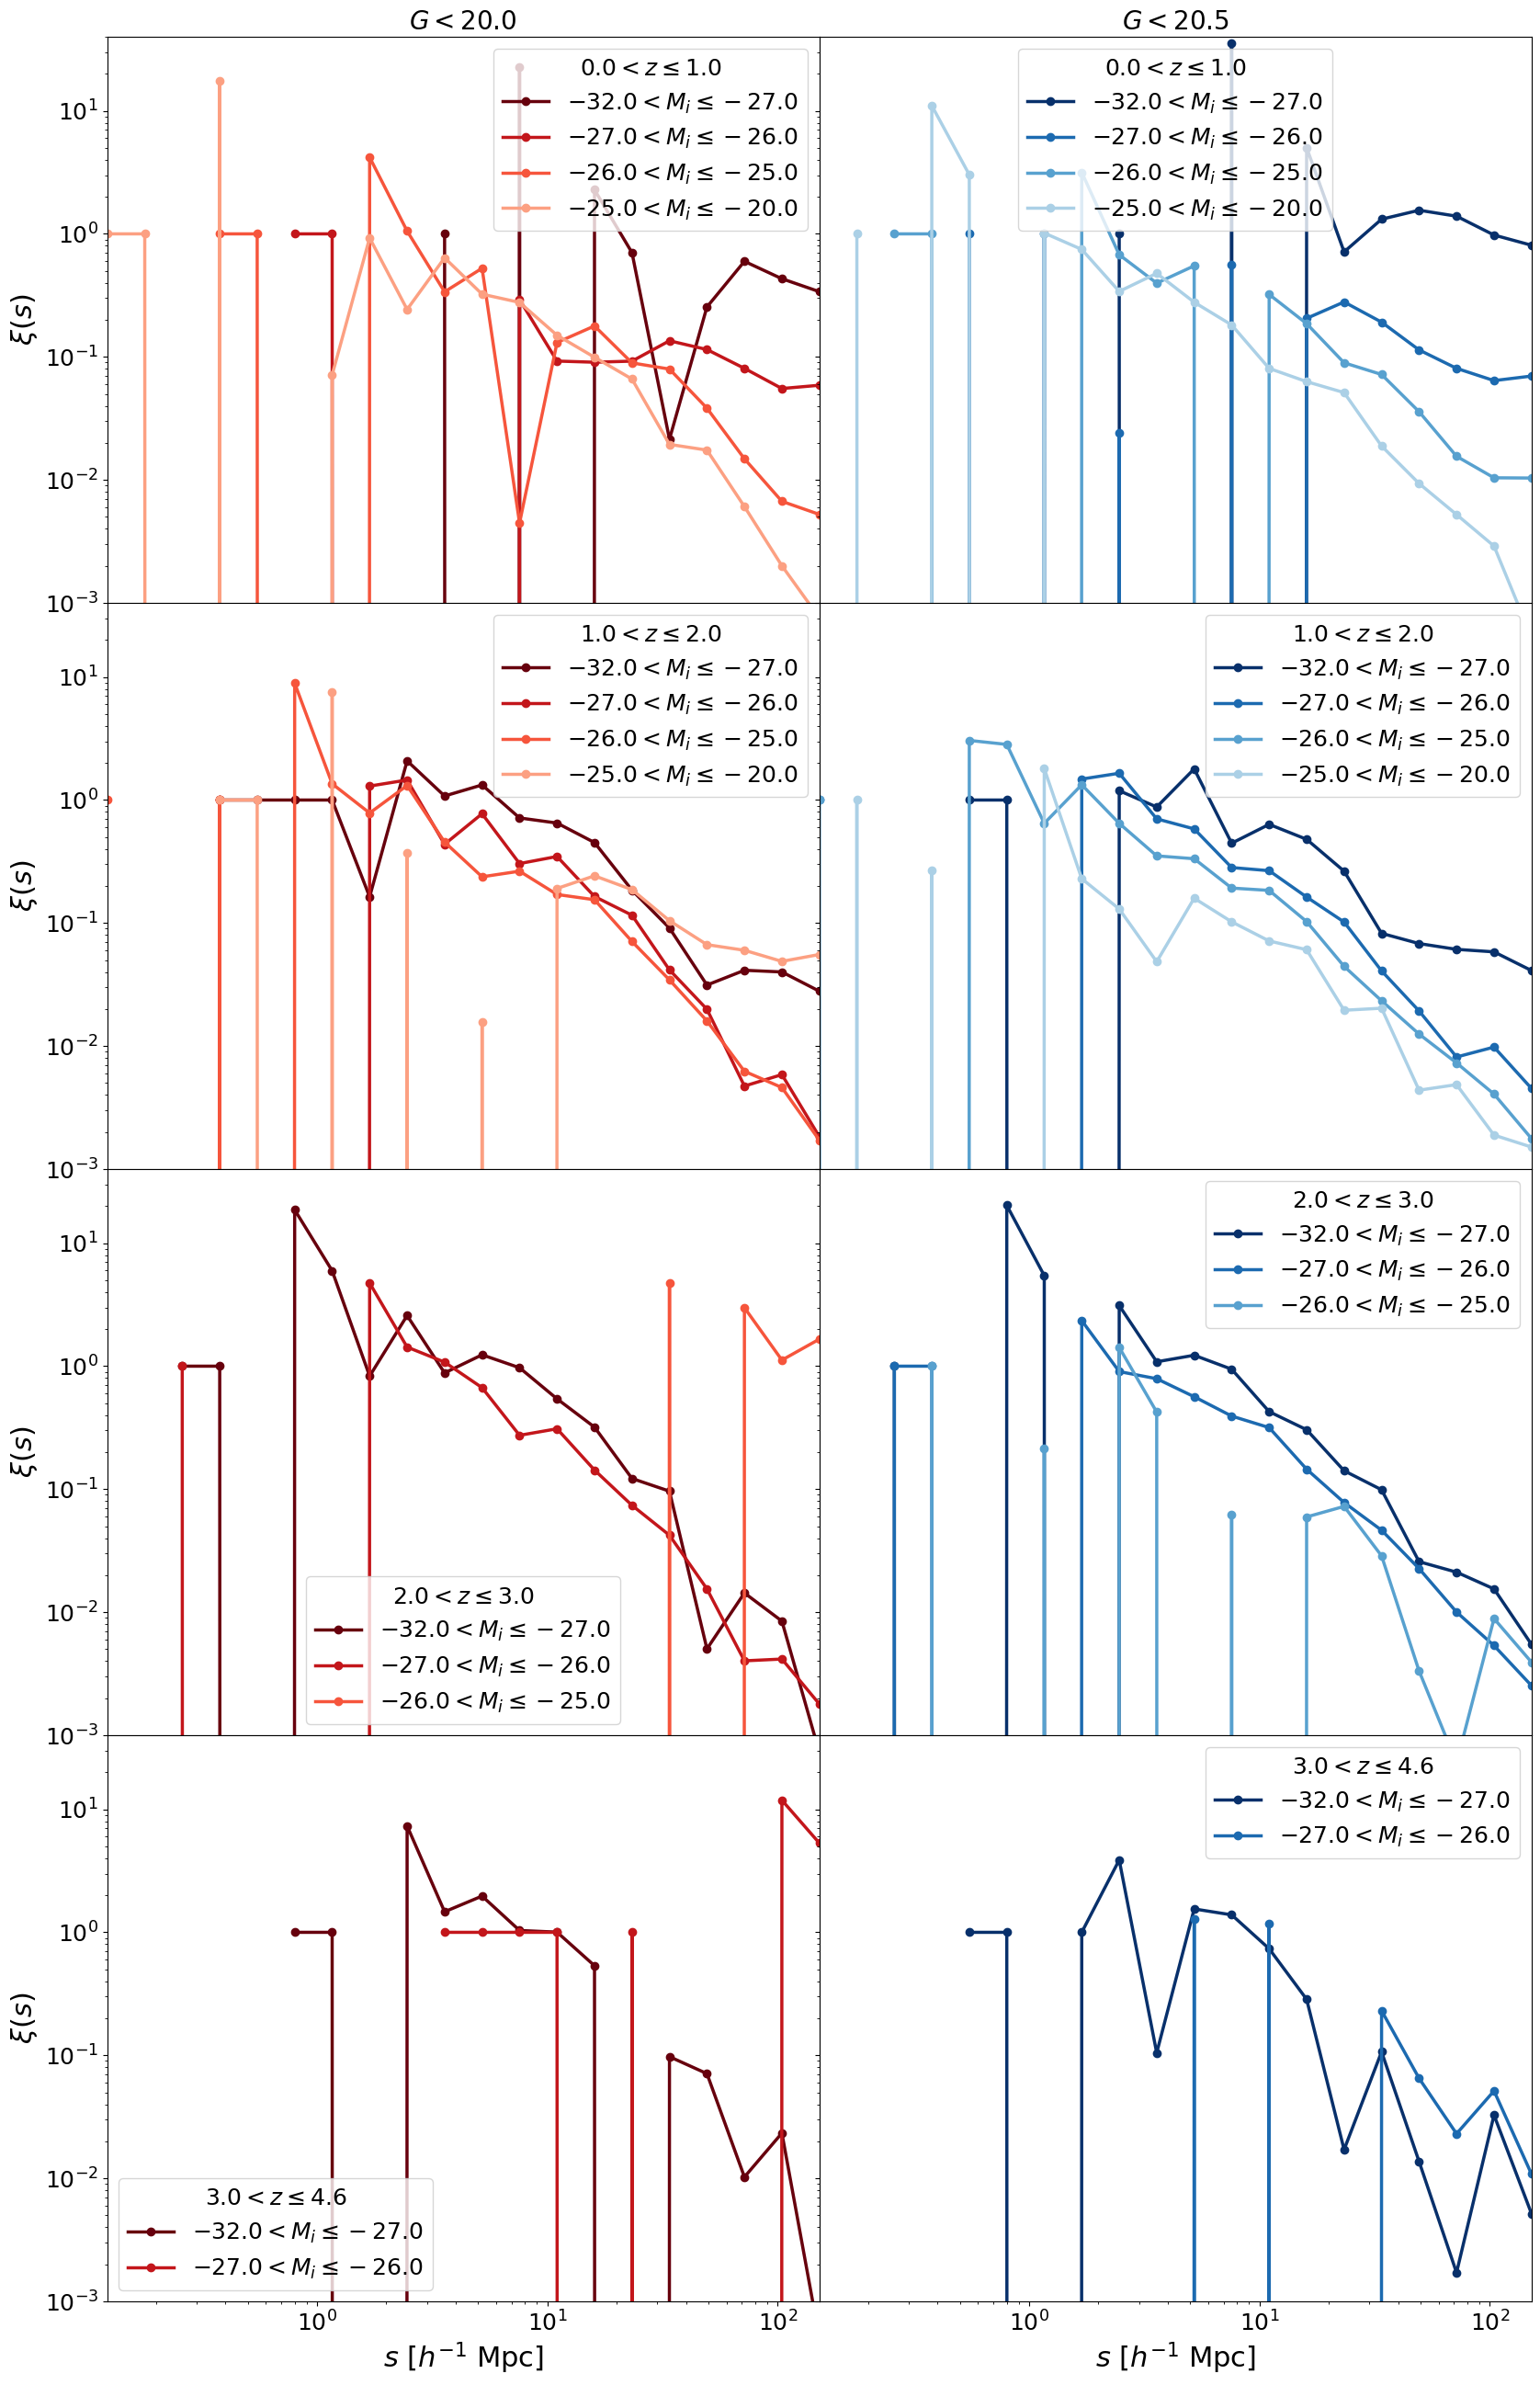

In [24]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in L_array:
            
            try:
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(sbins)[0], quaia.recenter(sbins)[-1])
        ax1.set_ylim(1e-3, 4e1)
        ax1.legend(title = z_labels[j], title_fontsize = 18)
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])
        if j == 3:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


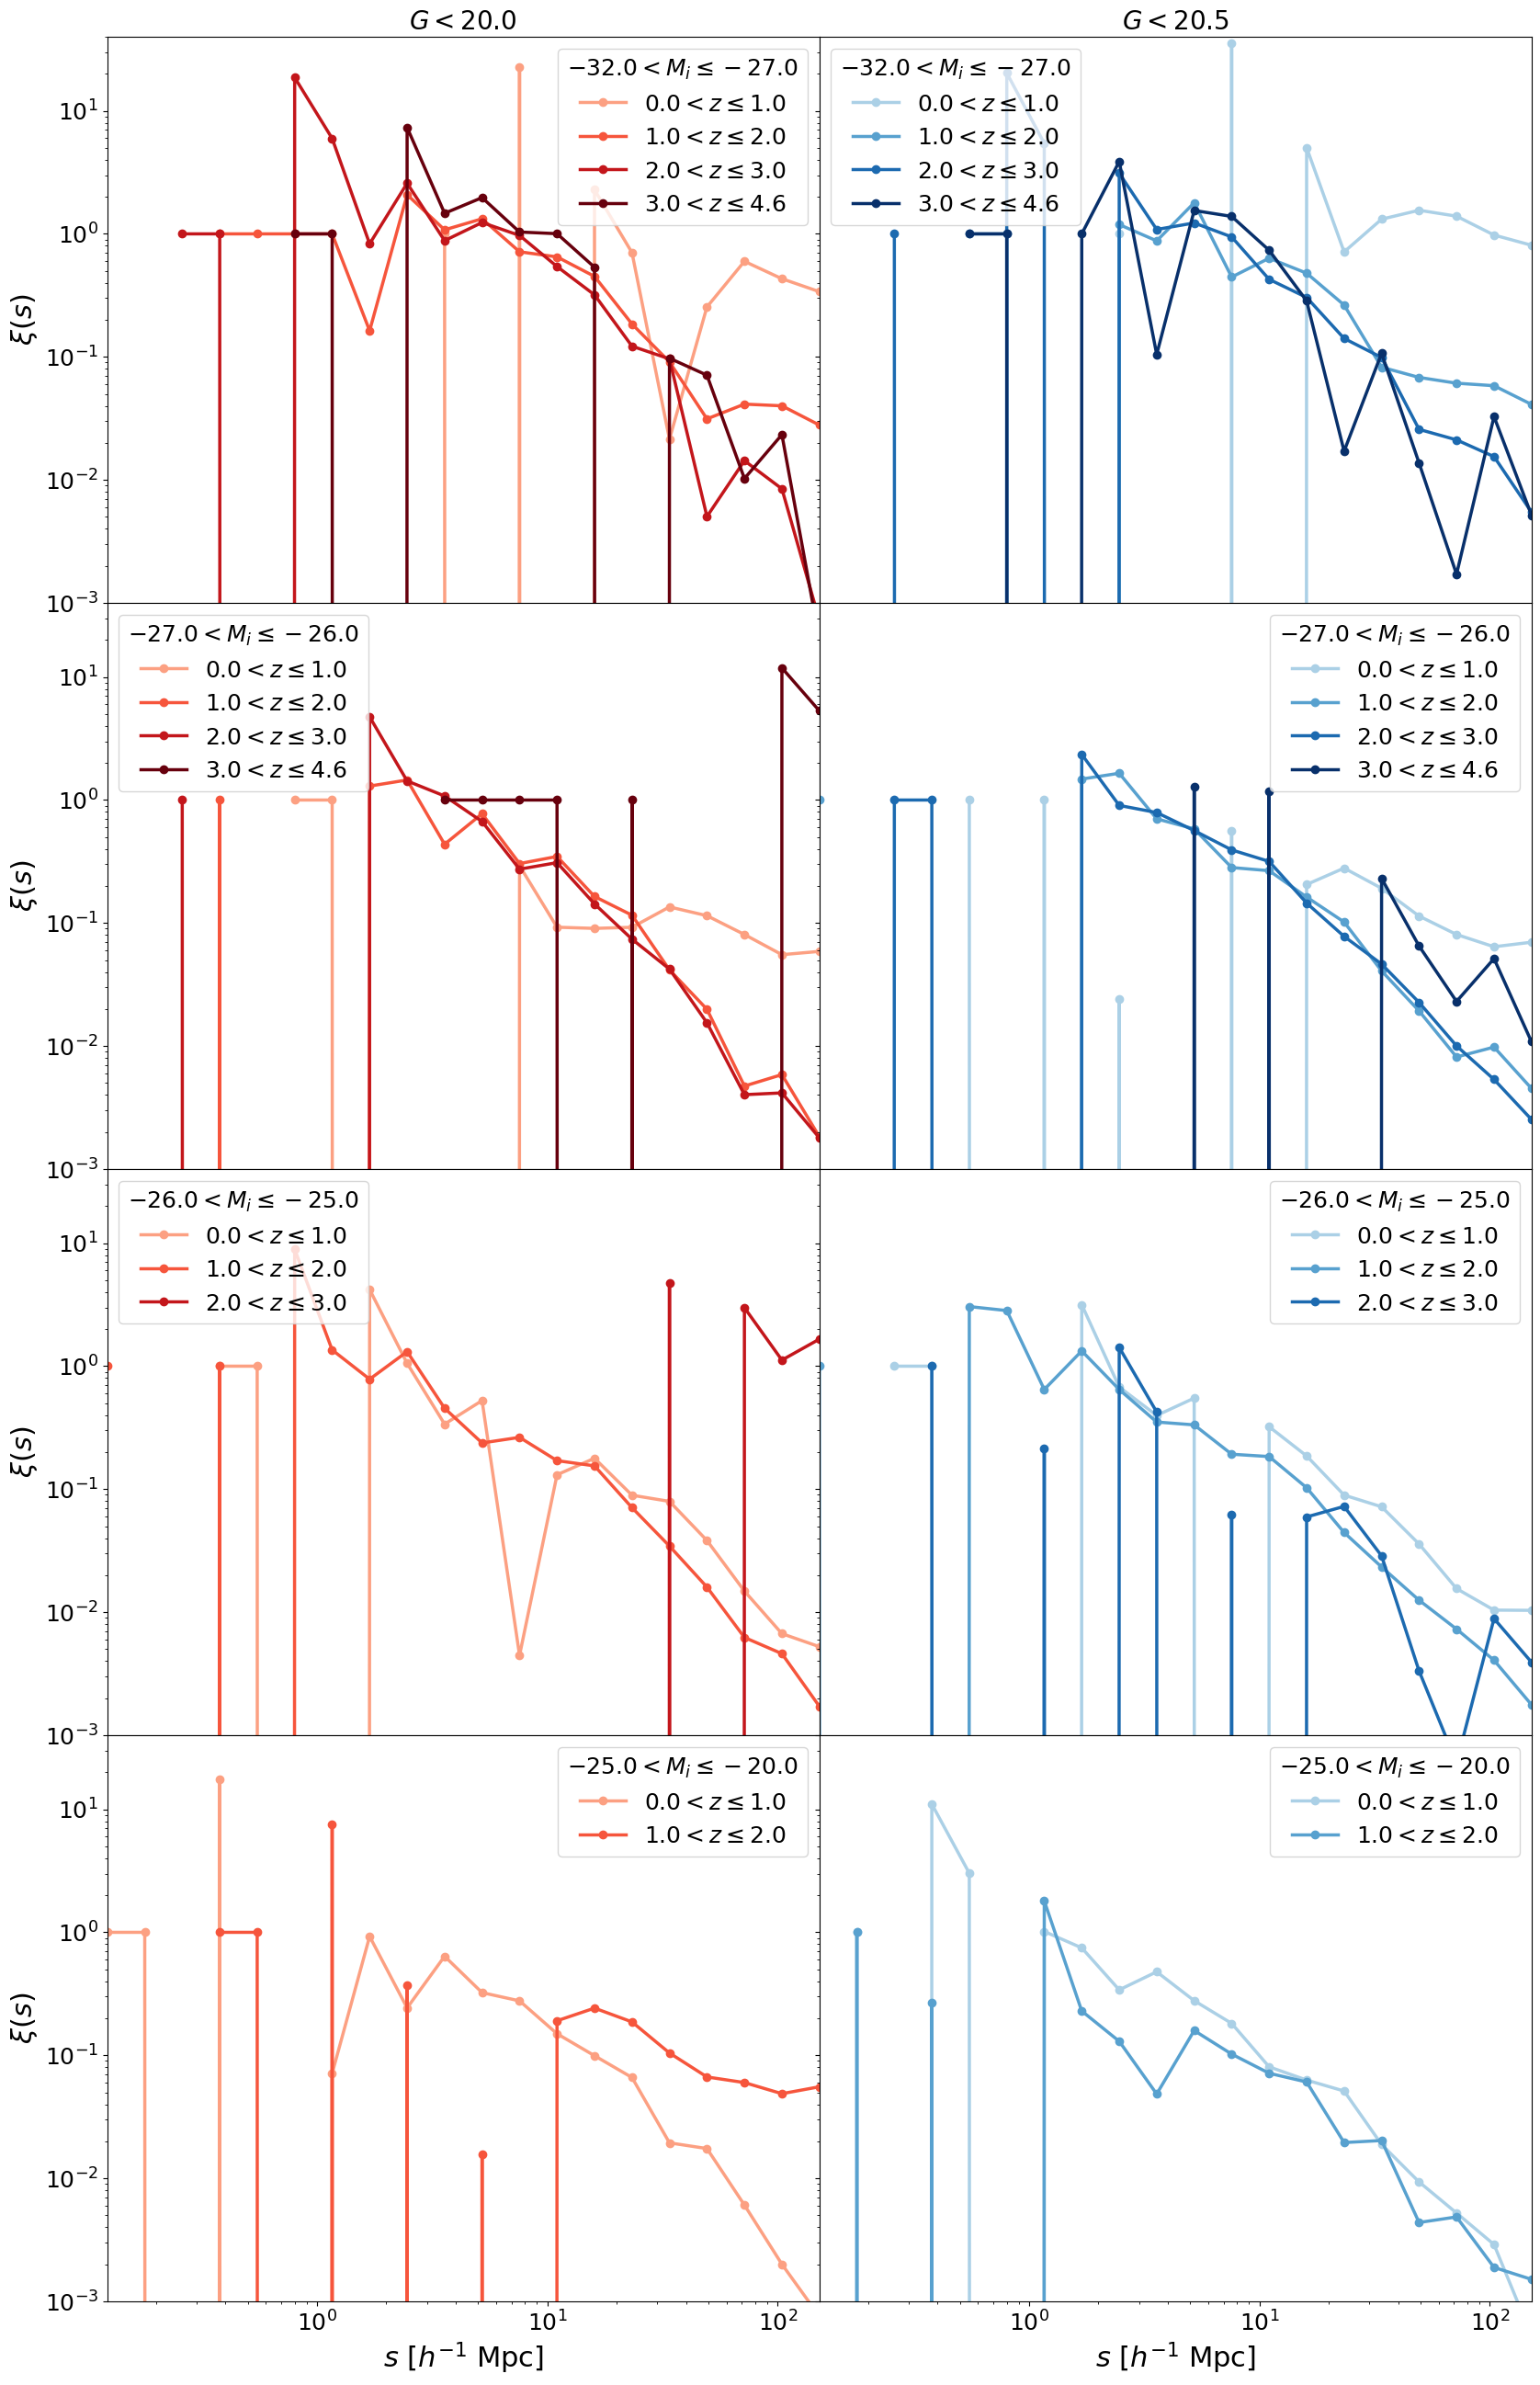

In [25]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in z_array:
            
            try:
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][k][j], label = z_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(sbins)[0], quaia.recenter(sbins)[-1])
        ax1.set_ylim(1e-3, 4e1)
        ax1.legend(title = L_labels[j], title_fontsize = 18)
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])
        if j == 3:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


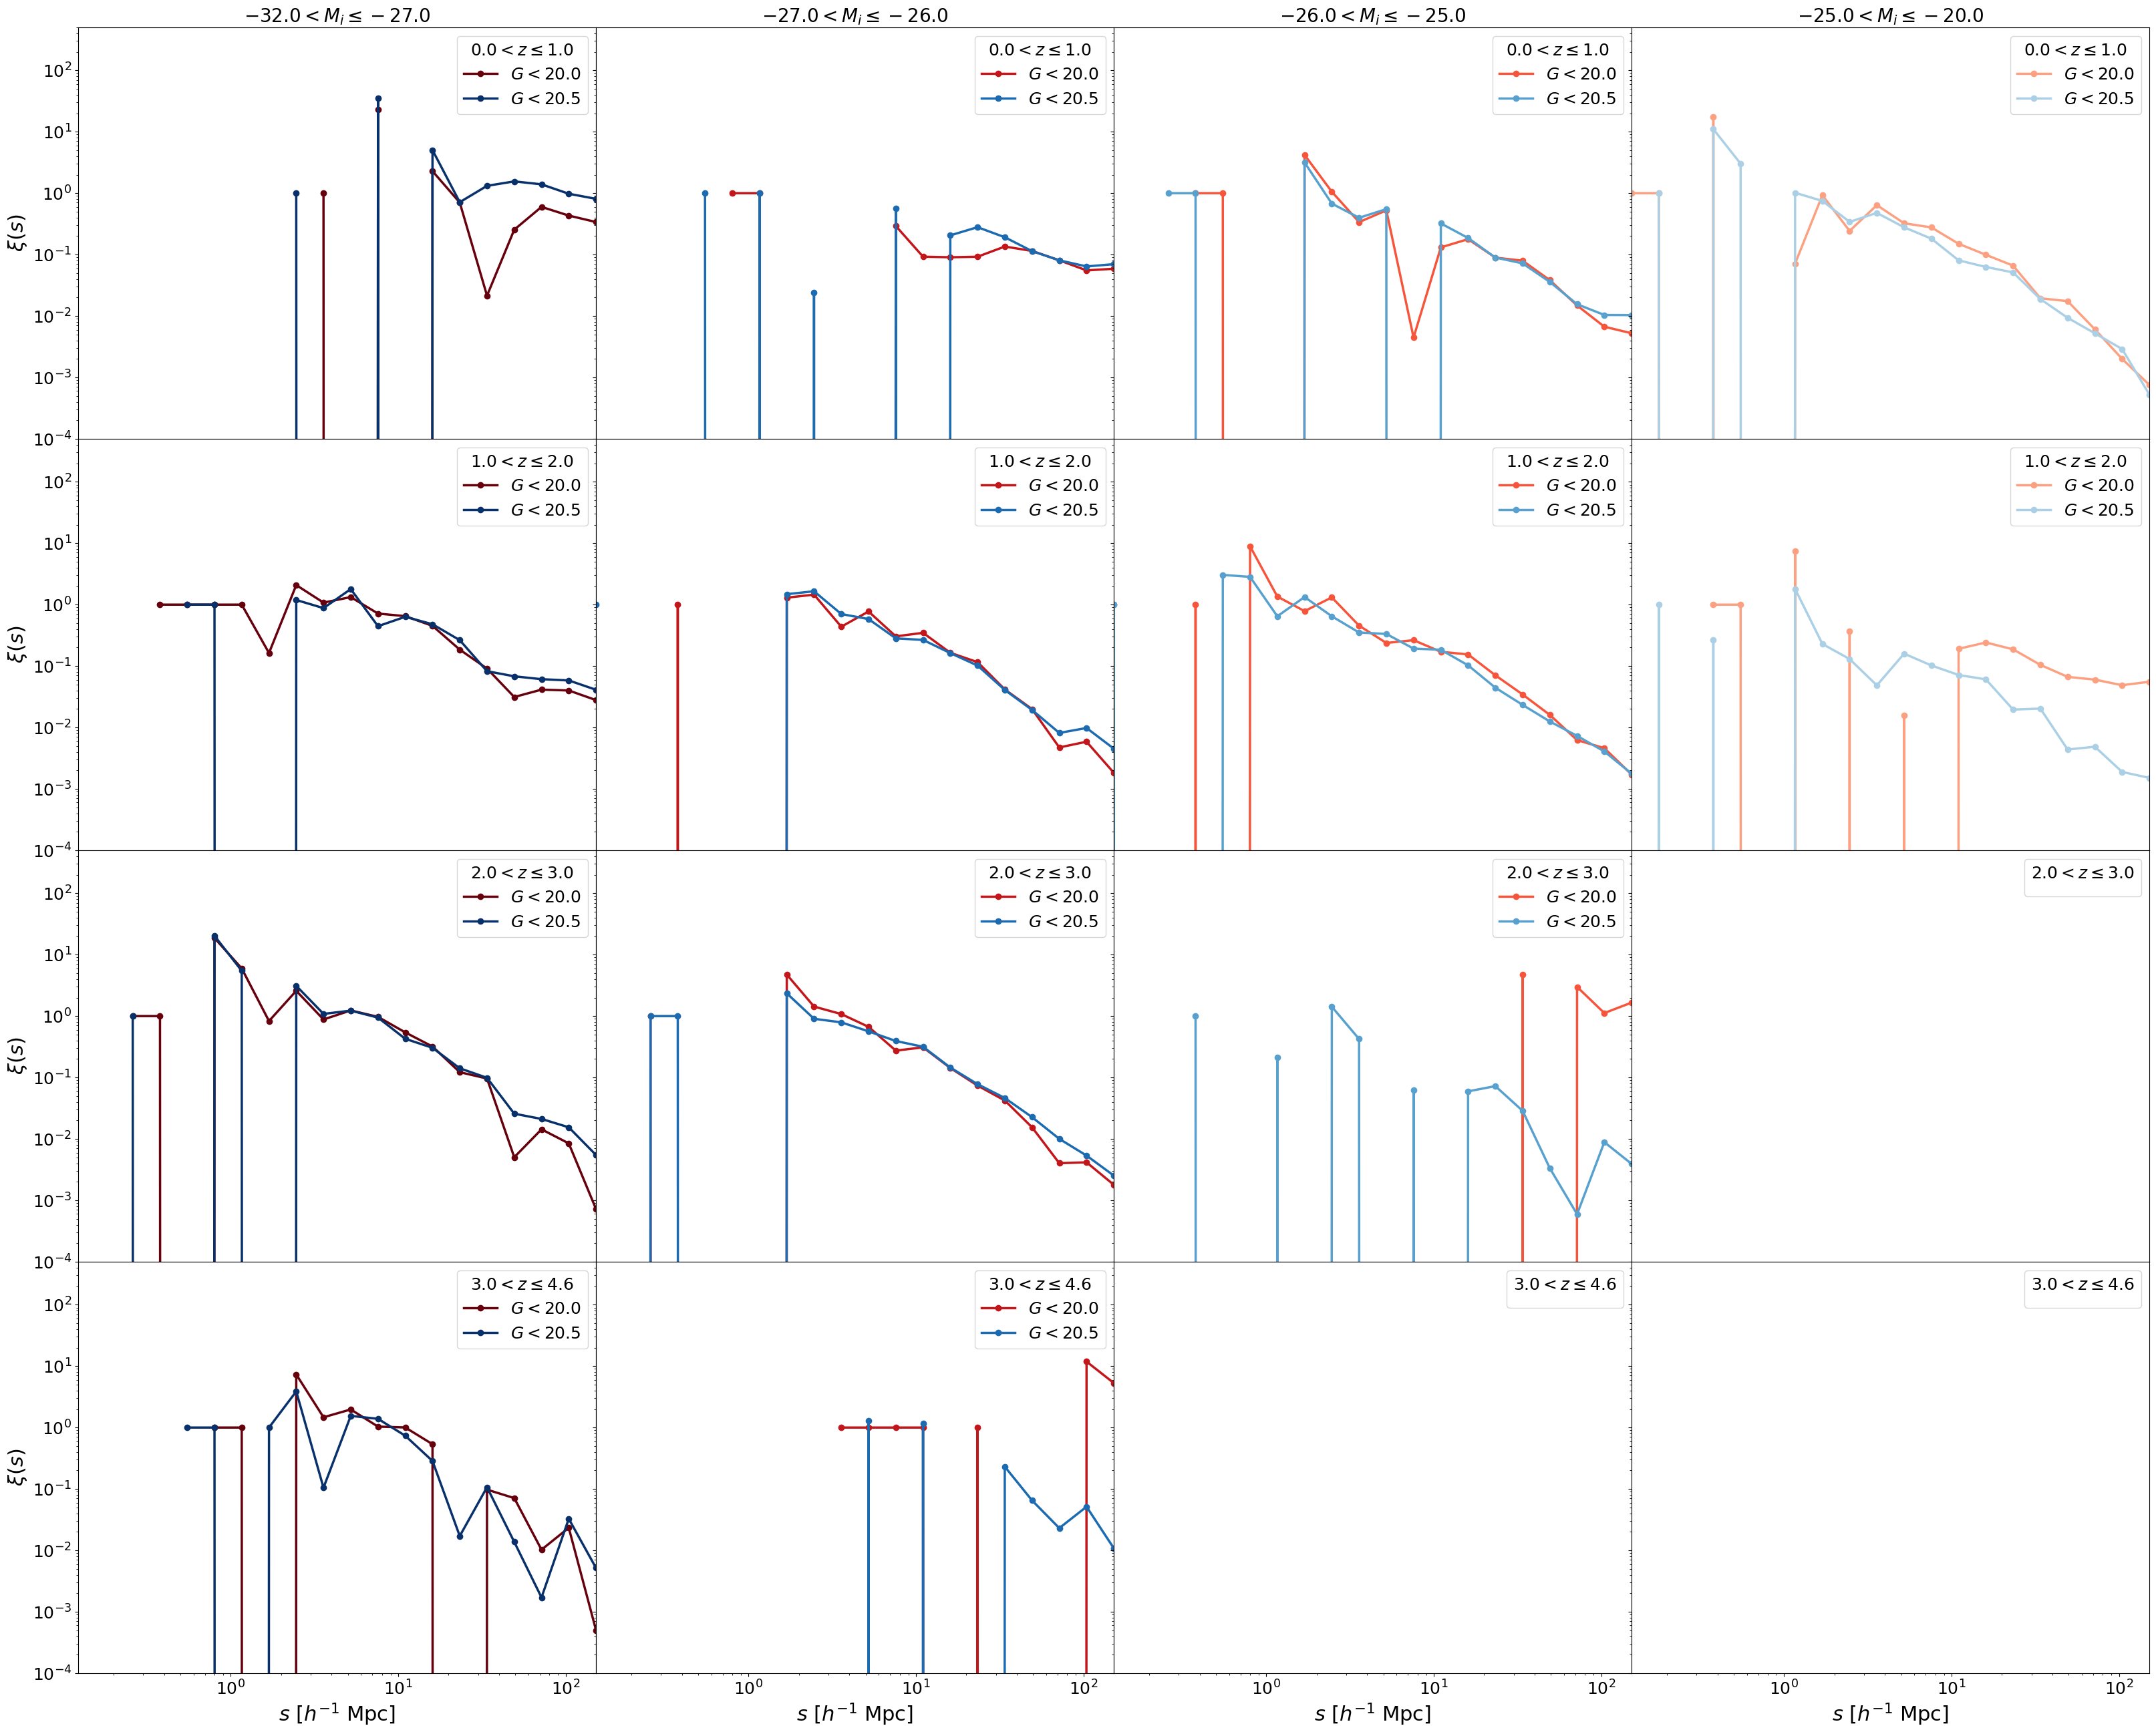

In [26]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in z_array:

    for k in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][j][k], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(L_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(sbins)[0], quaia.recenter(sbins)[-1])
        ax1.set_ylim(1e-4, 5e2)
        ax1.legend(title = z_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


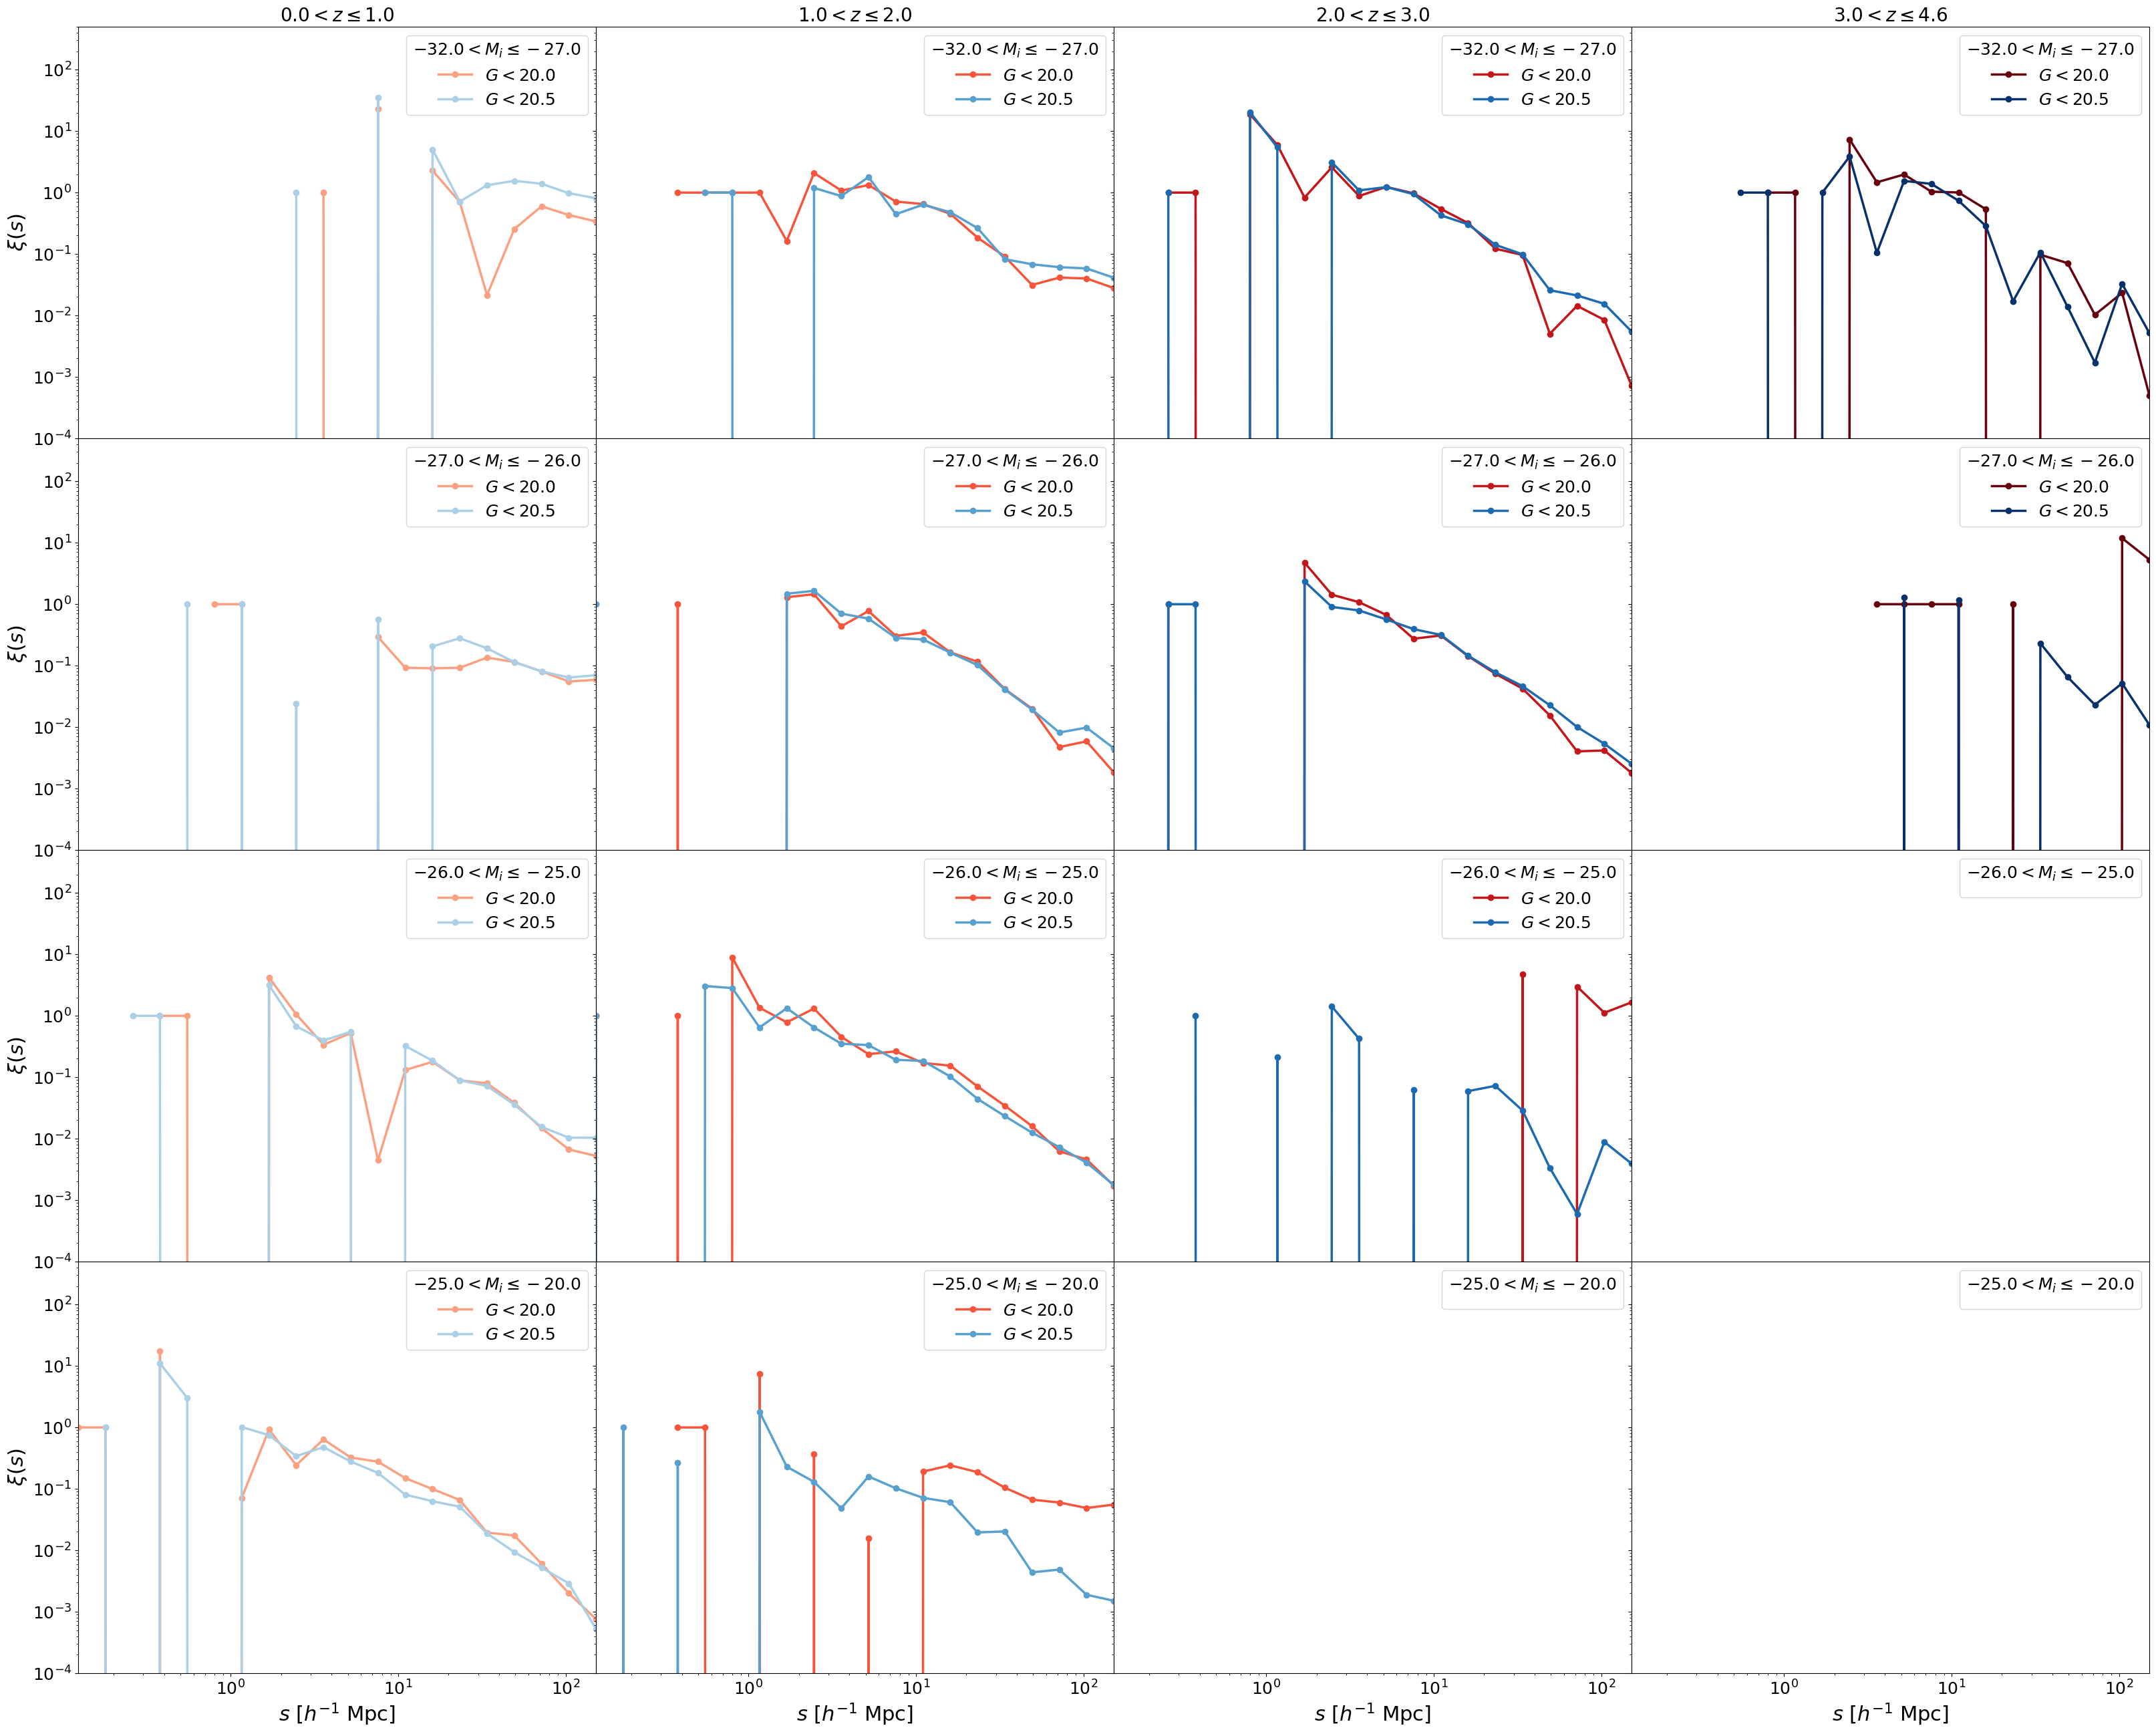

In [27]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in L_array:

    for k in z_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][k][j], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(z_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(sbins)[0], quaia.recenter(sbins)[-1])
        ax1.set_ylim(1e-4, 5e2)
        ax1.legend(title = L_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

## $w_p(r_p)$

In [28]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [29]:
pimax = 80 # 40 # 5000.0 # 40.0

In [ ]:
# plot data
wp, rpavg = {20.0: [], 20.5: []}, {20.0: [], 20.5: []}
for G in G_array:

    for j in z_array:
        
        wp_L = []
        rpavg_L = []
        for k in L_array:
            
            try:
                tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G, [j,k], True, ['z', 'L'], 
                                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                     method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                     n_bins = [None, None], mask = mask, 
                                                                                                     norm = 'percentile')
                
                wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                                                                  rbins = rbins, nbins = nbins, pimax = pimax)
                wp_L.append(wp_datahi_zbin0)
                rpavg_L.append(rpavg_datahi_zbin0)
                
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        wp[G].append(wp_L)
        rpavg[G].append(rpavg_L)       

G20.0_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0: 0.40              1038 vs 1730


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:726: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


G20.0_zmin0.0zmax1.0_Lmin-27.0Lmax-26.0: 0.40              5947 vs 9911


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:726: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


G20.0_zmin0.0zmax1.0_Lmin-26.0Lmax-25.0: 0.40              23500 vs 39167


...

/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:726: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:726: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0: 0.40              1116 vs 1860


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:726: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


G20.5_zmin0.0zmax1.0_Lmin-27.0Lmax-26.0: 0.40              6247 vs 10412


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in L_array:
            
            try:
        
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-2, 3e3)
        ax1.legend(title = z_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in z_array:
            
            try:
        
                ax1.plot(rpavg[G_array[i]][k][j], wp[G_array[i]][k][j], label = z_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-2, 3e3)
        ax1.legend(title = L_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in z_array:

    for k in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(L_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-2, 3e3)
        ax1.legend(title = z_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for k in z_array:

    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(rpavg[G_array[i]][k][j], wp[G_array[i]][k][j], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(z_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-2, 3e3)
        ax1.legend(title = L_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in L_array:
            
            try:
        
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k]/rpavg[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = z_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in z_array:
            
            try:
        
                ax1.plot(rpavg[G_array[i]][k][j], wp[G_array[i]][k][j]/rpavg[G_array[i]][k][j], label = z_labels[k], linewidth = 2.5, marker = 'o', 
                         color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = L_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in z_array:

    for k in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k]/rpavg[G_array[i]][j][k], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, 
                         marker = 'o', 
                 color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(L_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = z_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for k in z_array:

    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(rpavg[G_array[i]][k][j], wp[G_array[i]][k][j]/rpavg[G_array[i]][k][j], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, 
                         marker = 'o', 
                 color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(z_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = L_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in L_array:
            
            try:
        
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', 
                         color = cmaps[i][k])
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k]/rpavg[G_array[i]][j][k], linewidth = 2.5, marker = 'o', 
                         color = cmaps[i][k], linestyle = '--')
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = z_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in z_array:
            
            try:
        
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][k][j], label = z_labels[k], linewidth = 2.5, marker = 'o', 
                         color = cmaps[i][::-1][k])
                ax1.plot(rpavg[G_array[i]][k][j], wp[G_array[i]][k][j]/rpavg[G_array[i]][k][j], linewidth = 2.5, marker = 'o', 
                         color = cmaps[i][::-1][k], linestyle = '--')
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = L_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in z_array:

    for k in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][j][k], label = '$G<{}, \\xi(s)$'.format(G_array[i]), 
                         linewidth = 2.5, marker = 'o', color = cmaps[i][k])
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k]/rpavg[G_array[i]][j][k], label = '$G<{}, w_p(r_p)$'.format(G_array[i]), 
                         linewidth = 2.5, marker = 'o', color = cmaps[i][k], linestyle = '--')
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(L_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = z_labels[j], title_fontsize = 18, ncol = 2)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for k in z_array:

    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][k][j], label = '$G<{}, \\xi(s)$'.format(G_array[i]), 
                         linewidth = 2.5, marker = 'o', color = cmaps[i][::-1][k])
                ax1.plot(rpavg[G_array[i]][k][j], wp[G_array[i]][k][j]/rpavg[G_array[i]][k][j], label = '$G<{}, w_p(r_p)$'.format(G_array[i]), 
                         linewidth = 2.5, marker = 'o', color = cmaps[i][::-1][k], linestyle = '--')
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(z_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = L_labels[j], title_fontsize = 18, ncol = 2)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

## $w(\theta)$

In [50]:
# Create the bins array
# thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) 
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

In [51]:
# plot data
wtheta = {G_lo: [], G_hi: []}
for G in G_array:

    for j in z_array:
        
        wtheta_L = []
        for k in L_array:
            
            try:
                tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G, [j,k], True, ['z', 'L'], 
                                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                     method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                     n_bins = [None, None], z = False)
                
                wtheta_L.append(quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins))
                
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        wtheta[G].append(wtheta_L)    

G20.0_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0: 0.00              1730 vs 1730
DD: 0.0034089999999999997
DR: 0.012832999999999999
RR: 0.02862
G20.0_zmin0.0zmax1.0_Lmin-27.0Lmax-26.0: 0.00              9911 vs 9911
DD: 0.003826
DR: 0.108968
RR: 0.644925
G20.0_zmin0.0zmax1.0_Lmin-26.0Lmax-25.0: 0.01              38900 vs 39167
DD: 0.021723
DR: 0.99219
RR: 9.789506
G20.0_zmin0.0zmax1.0_Lmin-25.0Lmax-20.0: 0.43              84985 vs 149969
DD: 0.15138700000000005
DR: 6.788242
RR: 76.256941
G20.0_zmin1.0zmax2.0_Lmin-32.0Lmax-27.0: 0.00              36305 vs 36311
DD: 0.023833
DR: 0.910769
RR: 8.510028
G20.0_zmin1.0zmax2.0_Lmin-27.0Lmax-26.0: 0.07              124034 vs 132662
DD: 0.182698
DR: 9.299903
RR: 107.586555
G20.0_zmin1.0zmax2.0_Lmin-26.0Lmax-25.0: 0.43              99299 vs 173186
DD: 0.219545
DR: 9.734587
RR: 110.27396
G20.0_zmin1.0zmax2.0_Lmin-25.0Lmax-20.0: 0.49              13800 vs 27165
DD: 0.008365
DR: 0.21931399999999998
RR: 1.3691520000000001
G20.0_zmin2.0zmax3.0_Lmin-32.0Lmax-27

G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


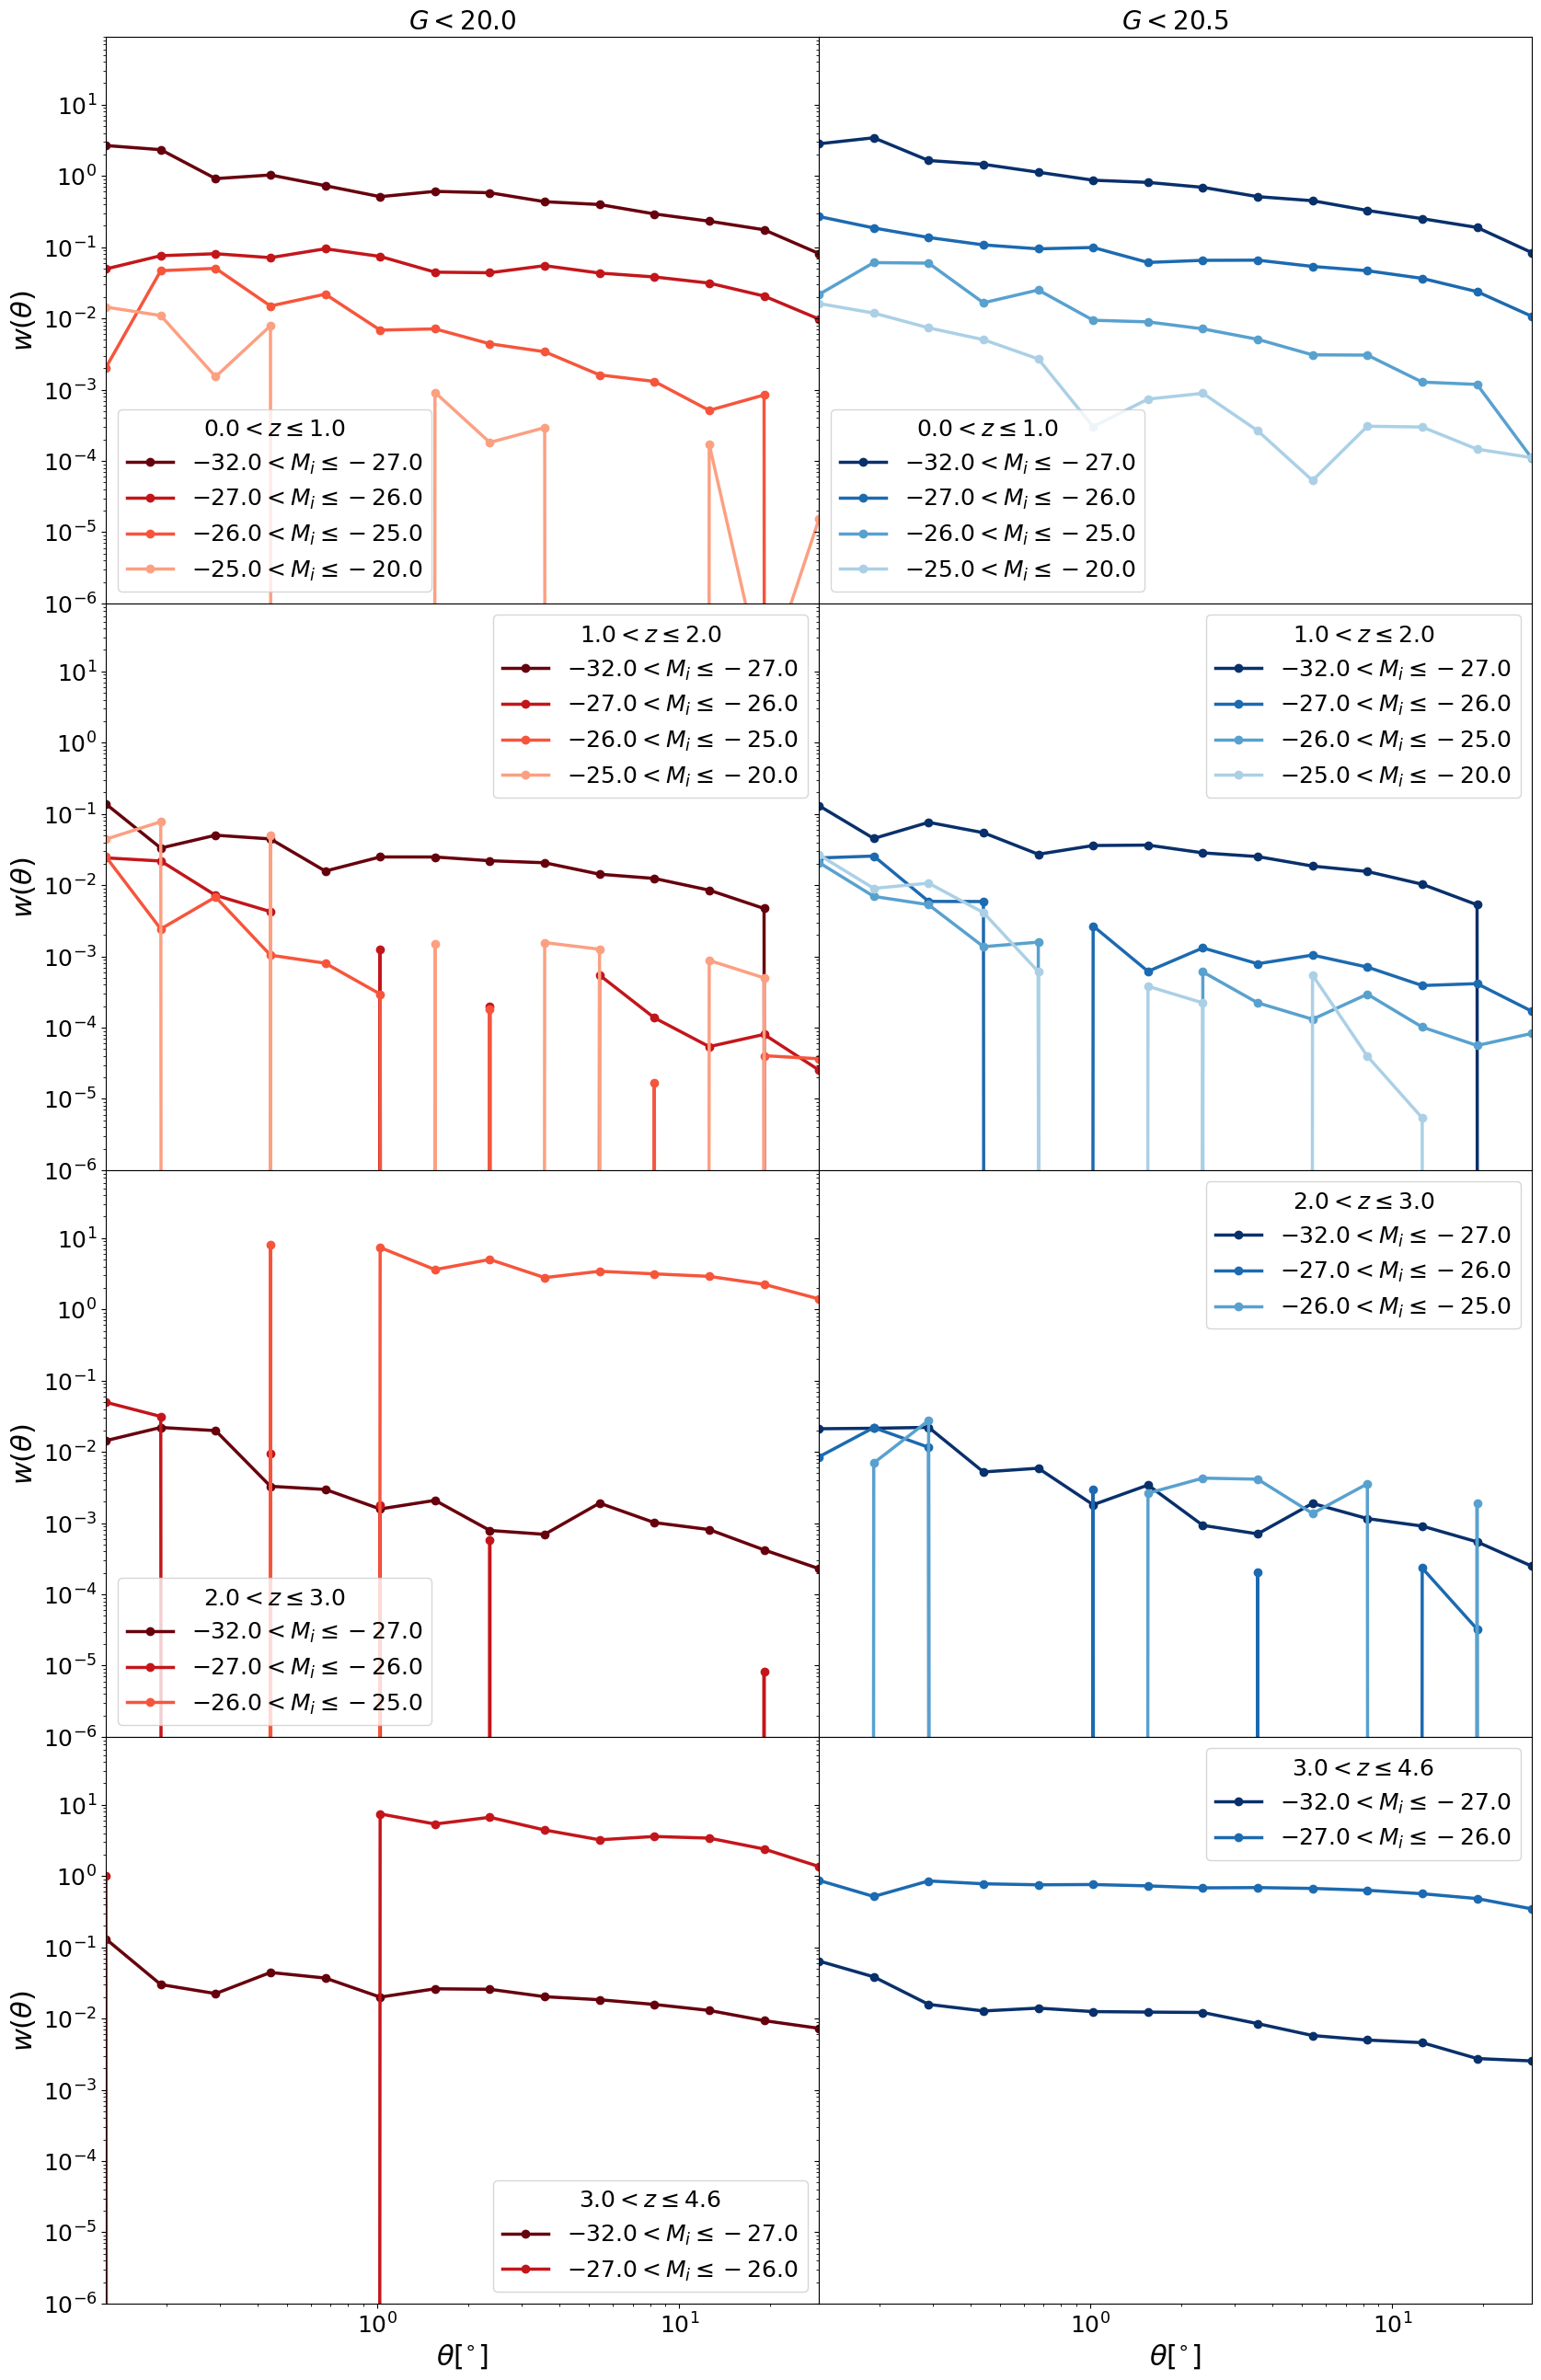

In [52]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in L_array:
            
            try:
        
                ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 9e1)
        ax1.legend(title = z_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$\theta[^{\circ}]$')
        else:
            ax1.set_xticklabels([])

plt.show()

G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


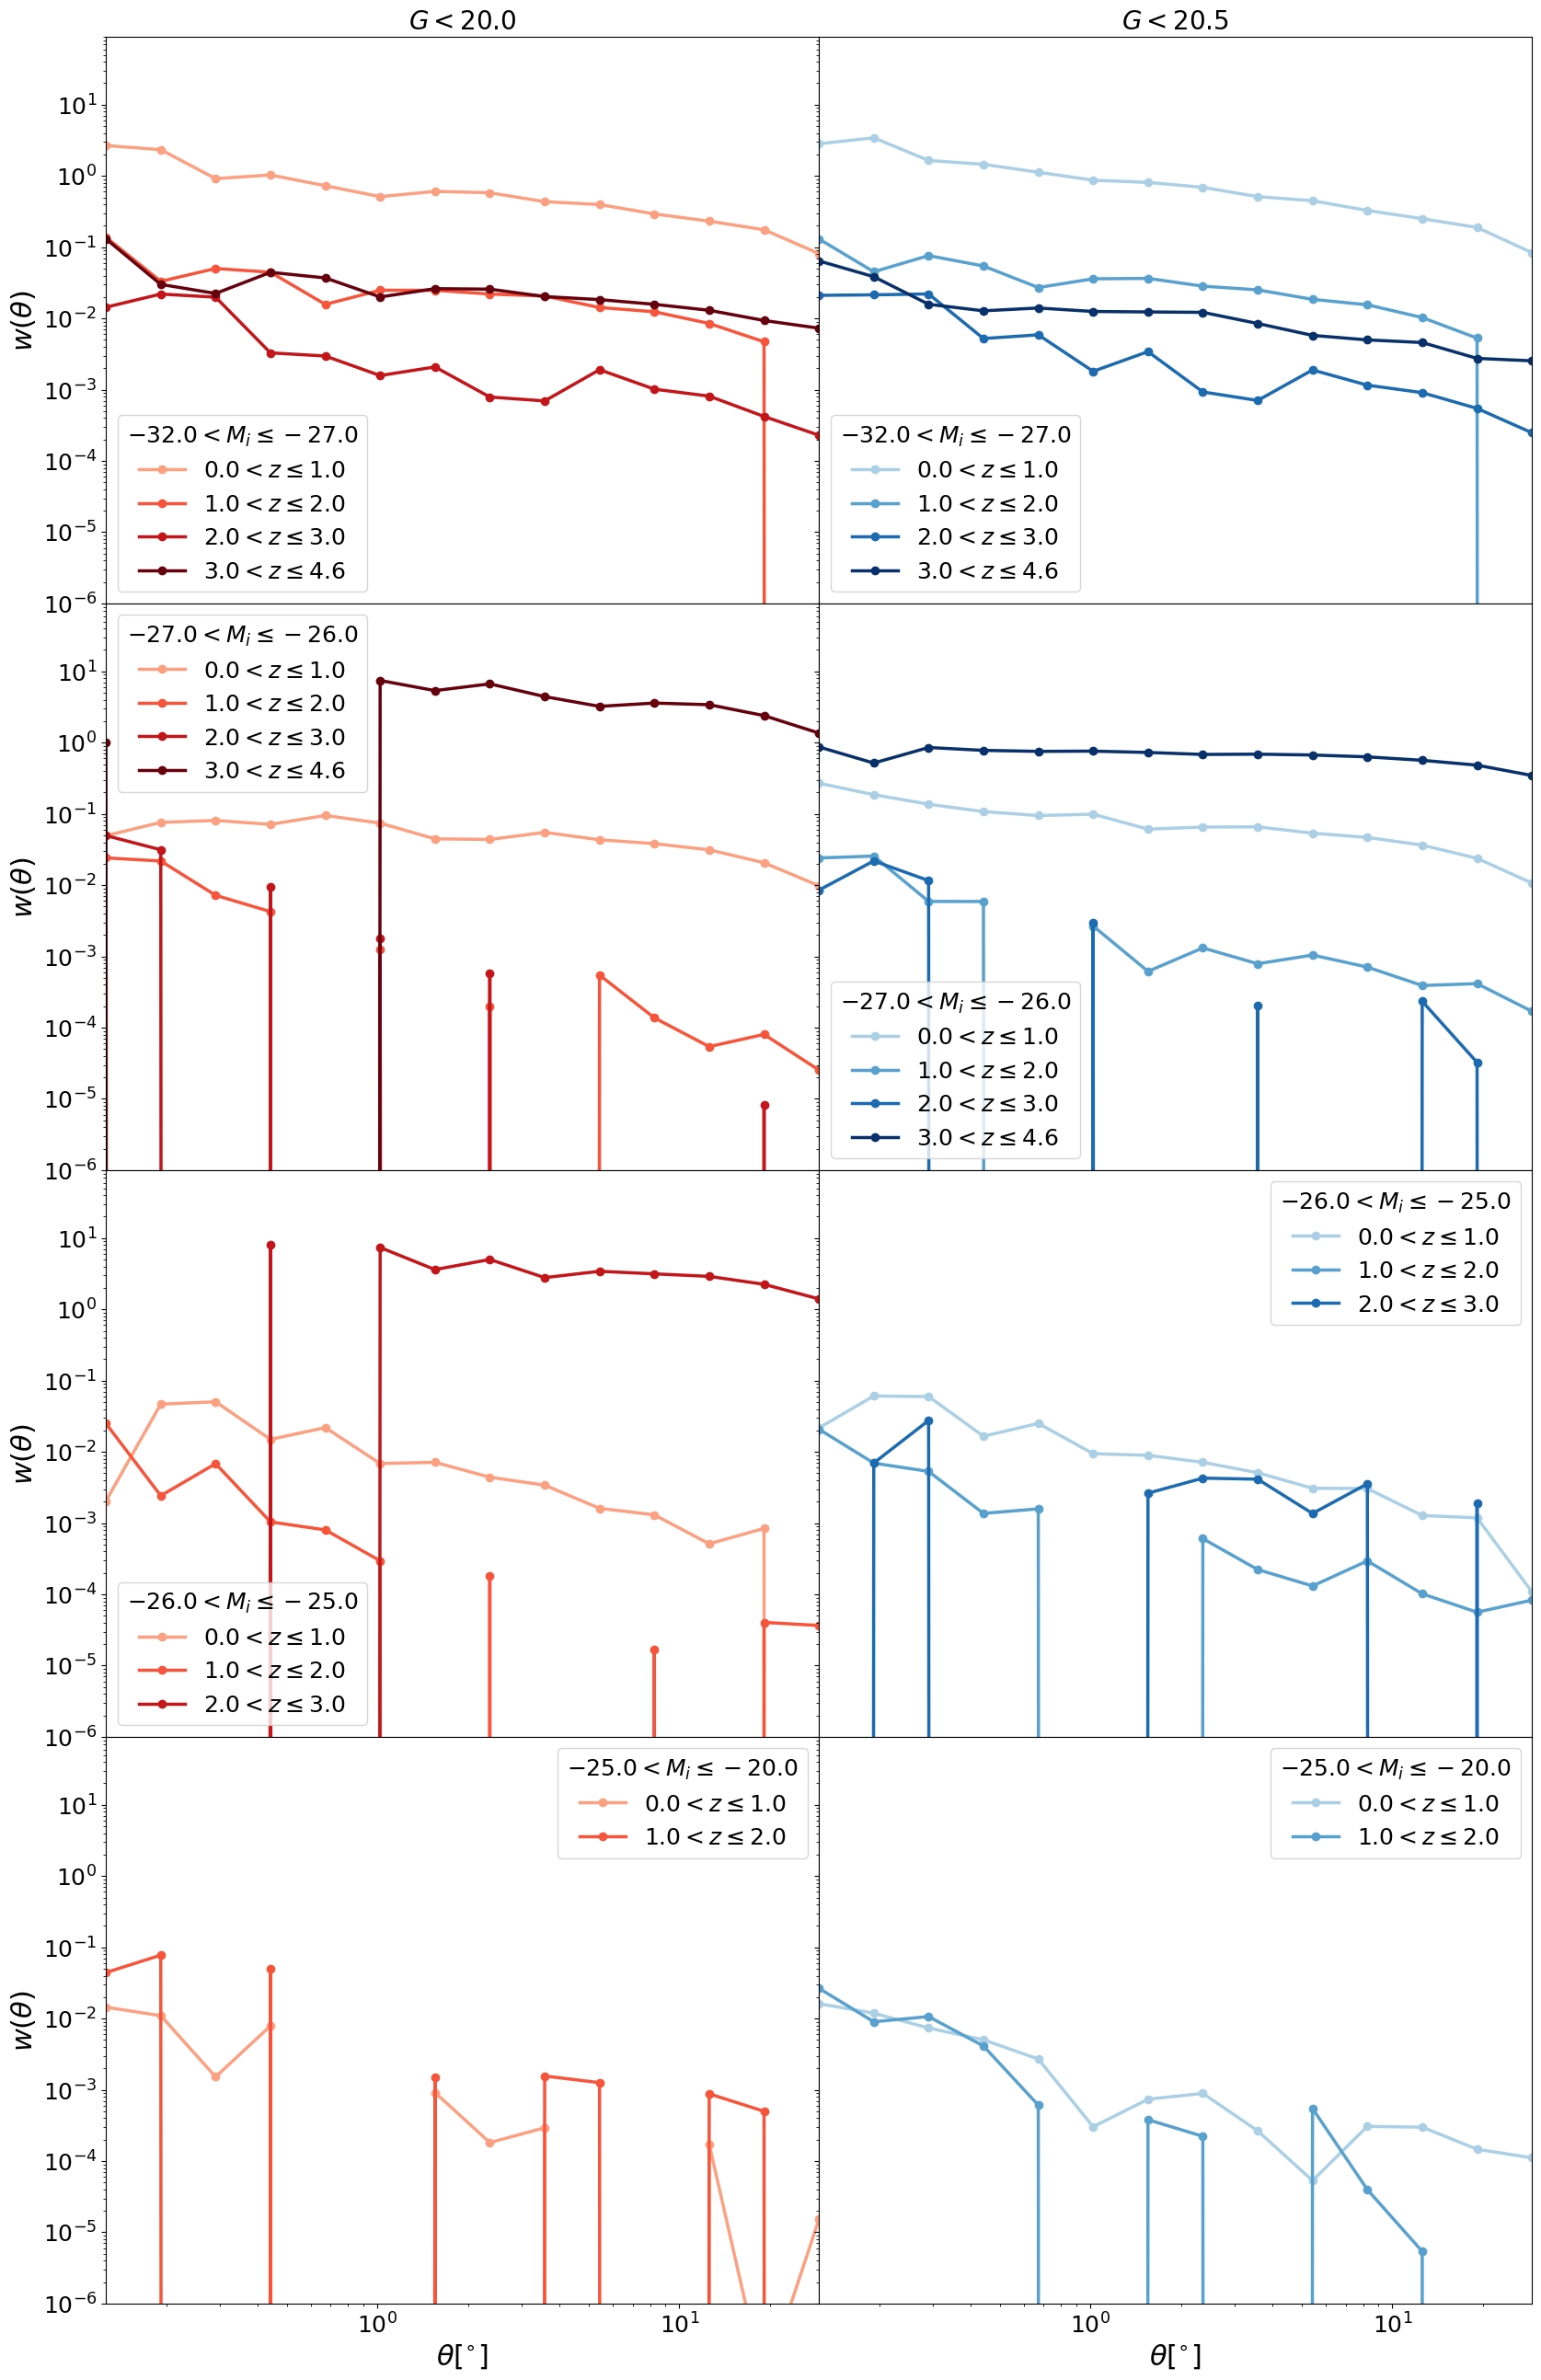

In [86]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in z_array:
            
            try:
        
                ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][k][j], label = z_labels[k], linewidth = 2.5, marker = 'o', 
                         color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 9e1)
        ax1.legend(title = L_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$\theta[^{\circ}]$')
        else:
            ax1.set_xticklabels([])

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


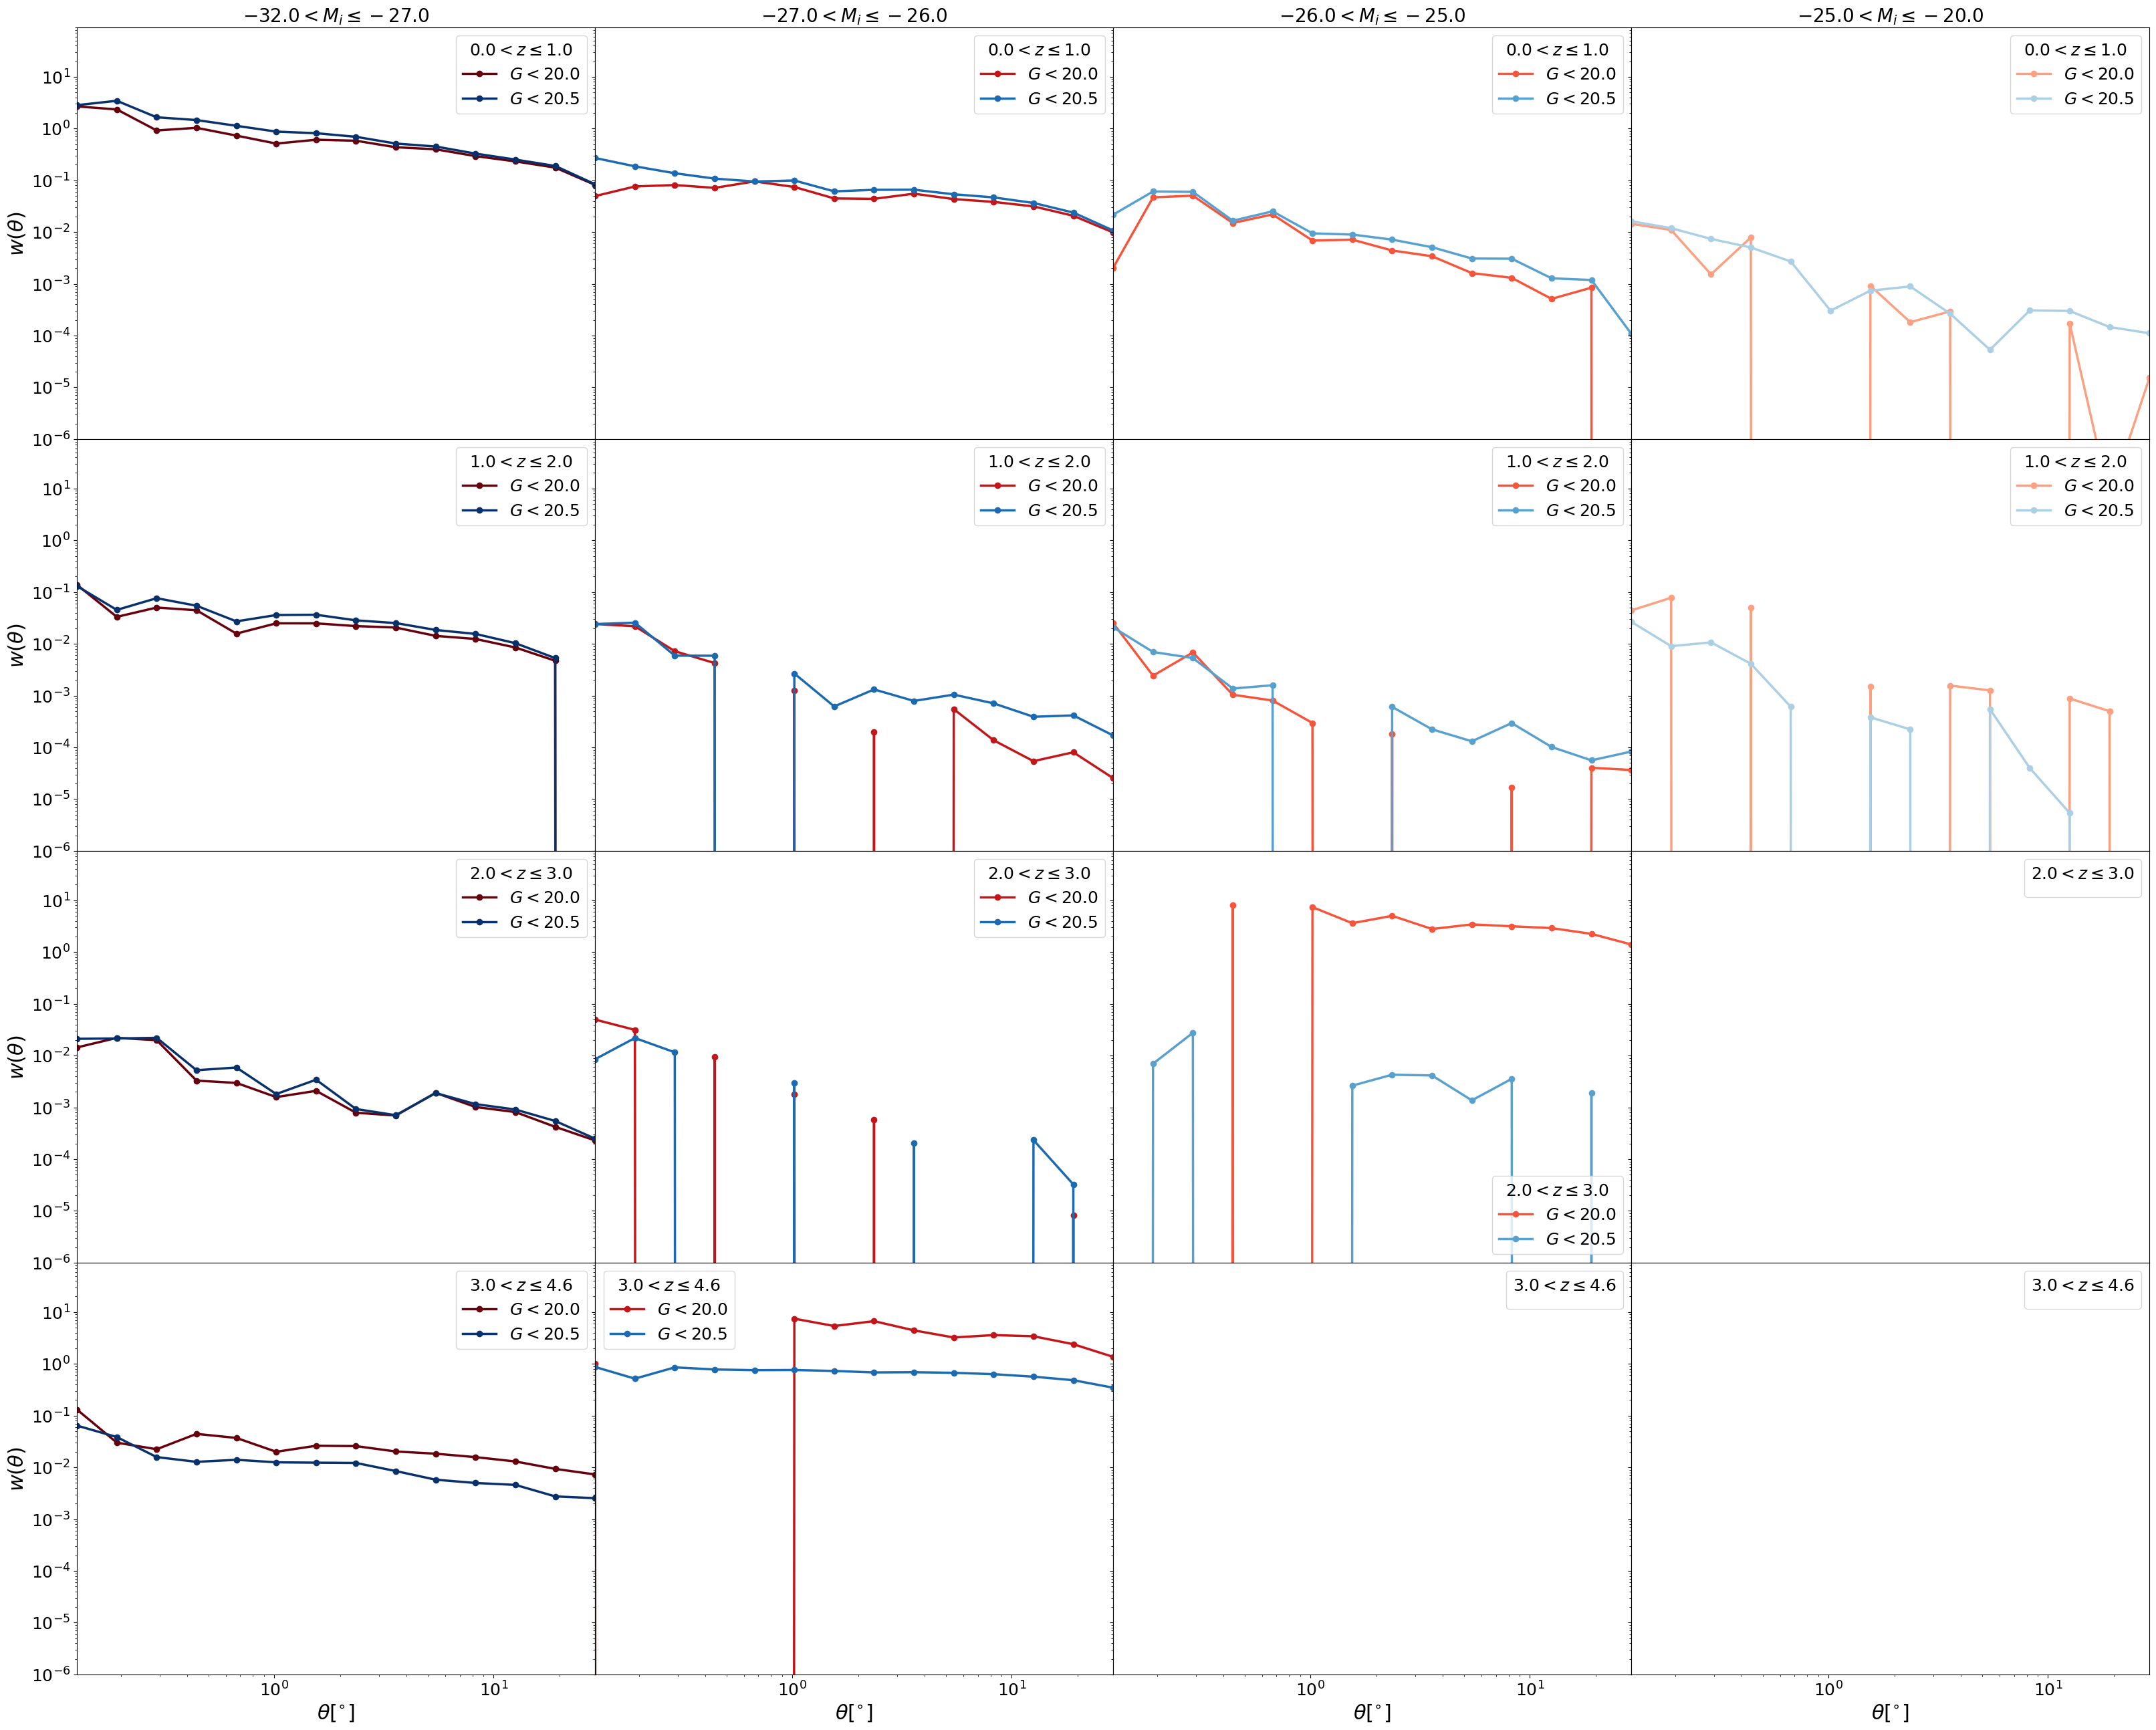

In [54]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in z_array:

    for k in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][j][k], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(L_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 9e1)
        ax1.legend(title = z_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$\theta[^{\circ}]$')
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


G20.0_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.0_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.0_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


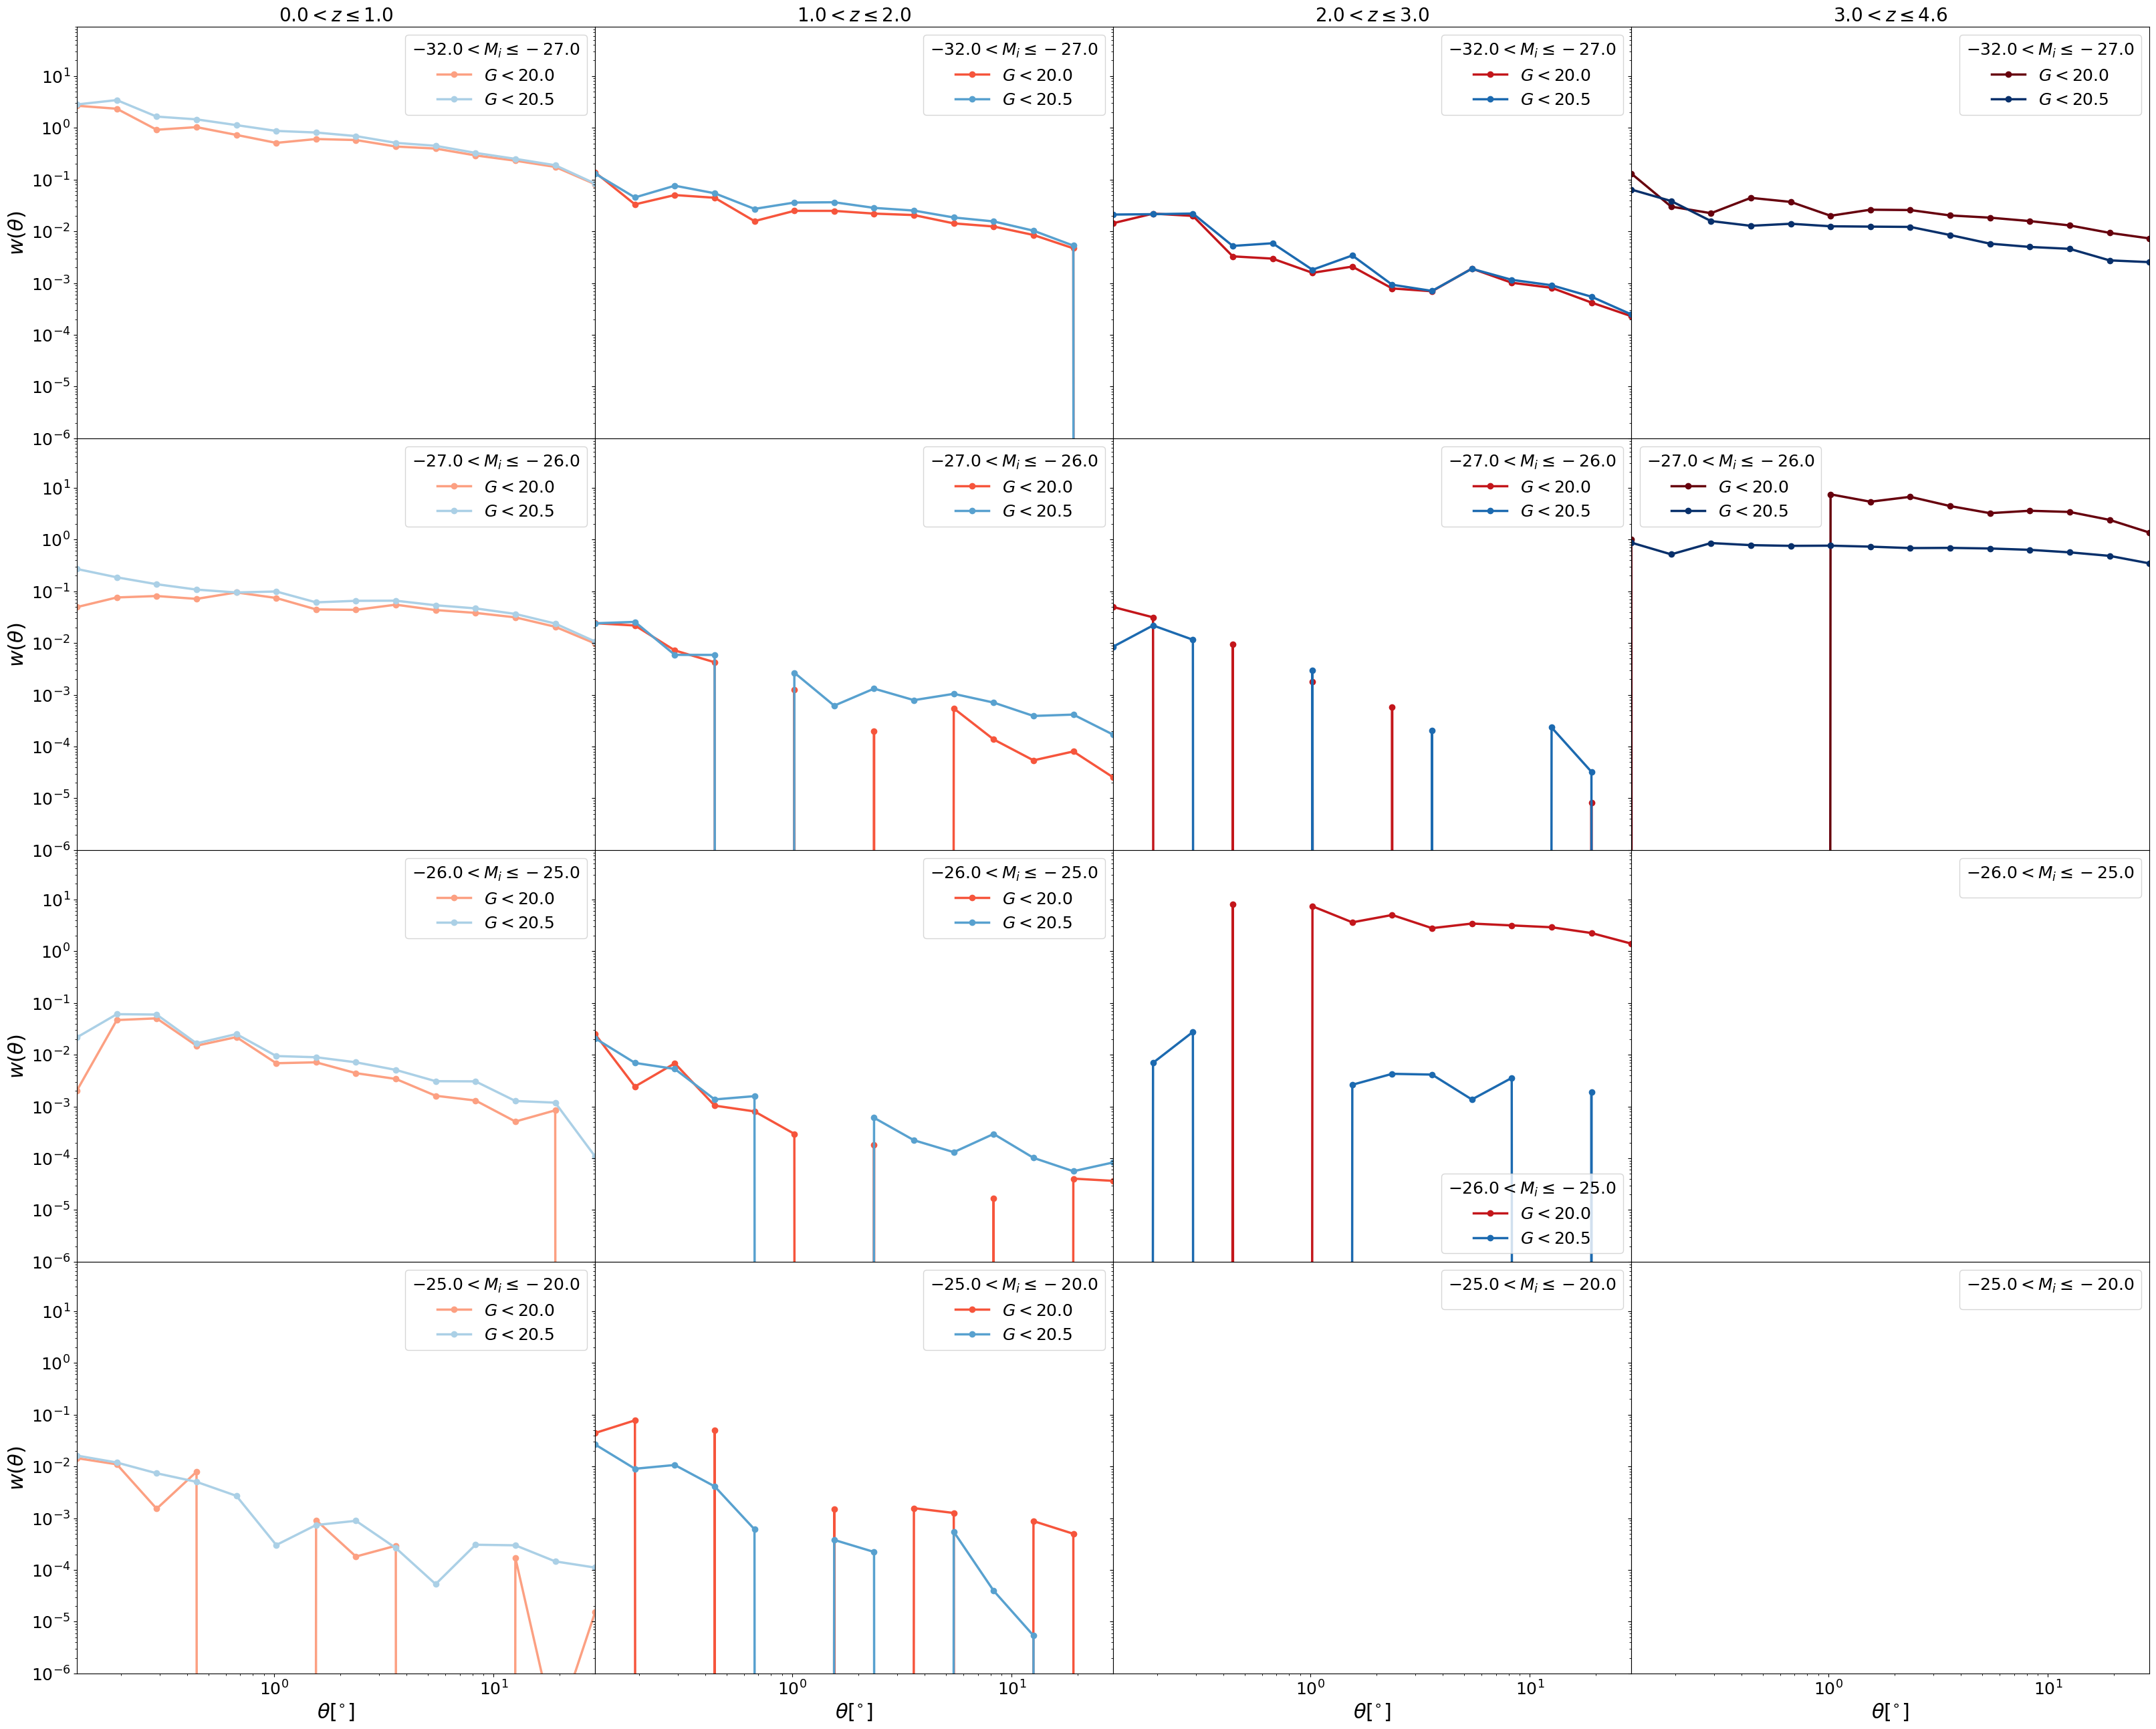

In [88]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for k in z_array:

    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][k][j], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(z_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 9e1)
        ax1.legend(title = L_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$\theta[^{\circ}]$')
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])

plt.show()